## 08 Trajectory Microenvironment Interactions

**What this notebook does:**  
Integrates PDAC pseudotime trajectories with microenvironment changes and ligand-receptor
interaction proxies across both modalities:

1. **IMC (multiplexed imaging)** — fibroblast activation, immune composition, and spatial
   co-localisation changes along the PDAC ductal niche trajectory
2. **Xenium (spatial transcriptomics)** — same axes plus gene-level fibroblast/immune status
   and targeted ligand-receptor product scores (CXCL12/CXCR4, AREG/EGFR, CSF1/CSF1R, CCL2/CCR2…)
3. **Branch-time niche state atlas** — each branch split into early/mid/late pseudotime thirds,
   revealing which microenvironment features transition most dramatically *within* each branch
4. **Cross-modality interpretation table** — top-ranked changes pooled from both datasets

**sv.tl functions used:** `add_branch_time_bins`, `zscore_series`  
**Run after:** `06_dev_graph_pseudotime_v2_combined_exp_2_3_4_5.ipynb` and `07_xenium_03_pooled_pseudotime.ipynb`


In [1]:
from pathlib import Path
# DATA AVAILABILITY CHECK
import os
# Trajectory interaction analysis requires pseudotime results
_root = Path("/Users/shihongwu/SpatioEv")
_mi_dir = _root / "data" / "combined_exp_2_3_4_5"
_xenium_dir = _root / "data" / "xenium_pancreas_10x"
_required_files = [_mi_dir, _xenium_dir]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


# Trajectory Microenvironment and Communication Atlas

This notebook asks what changes in fibroblasts and immune cells along the SpatioEv epithelial-niche trajectories, and which spatially local ligand-receptor interaction proxies change along the Xenium trajectory.

Method framing:

- For neighborhood/state changes, we use niche-centered surrounding-cell summaries and branch/pseudotime trend analysis.
- For spatial cell-cell communication, we use a CellPhoneDB/CellChat-style ligand-receptor expression product, but constrain the source/target expression to cells in each epithelial niche and its local graph surround. This is a lightweight approximation to spatial CCC methods such as Squidpy ligand-receptor tests and COMMOT spatially constrained communication.
- For downstream interpretation, we treat the ligand-receptor results as candidates for validation, in the spirit of NicheNet/CCC workflows, not as proof of signaling.

Key references:

- Squidpy neighborhood enrichment and ligand-receptor analysis: https://doi.org/10.1038/s41592-021-01358-2
- CellPhoneDB protocol: https://doi.org/10.1038/s41596-020-0292-x
- CellChat: https://doi.org/10.1038/s41467-021-21246-9
- COMMOT: https://doi.org/10.1038/s41592-022-01728-4
- NicheNet: https://doi.org/10.1038/s41592-019-0667-5


In [2]:
%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import json
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import sparse
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.neighbors import BallTree

import scanpy as sc
import spatioev as sv
from spatioev.tl import add_branch_time_bins
from spatioev.tl.pseudotime import zscore_series as sv_zscore_series

# ── Nature/Cell publication rcParams ─────────────────────────────────────────
_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial","Helvetica","DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
}
mpl.rcParams.update(_pub_rc)

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path("/Users/shihongwu/SpatioEv")
OUTPUT_DIR = ROOT / "notebooks" / "results" / "trajectory_microenvironment_interactions"
FIG_DIR    = OUTPUT_DIR / "figures"
TABLE_DIR  = OUTPUT_DIR / "tables"
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MI_DIR          = ROOT / "data" / "combined_exp_2_3_4_5"
XENIUM_DIR      = ROOT / "data" / "xenium_pancreas_10x"
XENIUM_NICHE_DIR = XENIUM_DIR / "niche_features"
XENIUM_PTIME_DIR = XENIUM_DIR / "pseudotime"

# Niche keys — must match the column names in each modality's result df
MI_KEY     = "pancreatic ductal epithelium_mask_component"   # IMC niche ID
XENIUM_KEY = "xenium_ductal_epithelium_component"            # Xenium niche ID
RANDOM_STATE = 42

# ── Colour palettes ───────────────────────────────────────────────────────────
DISEASE_PALETTE  = {"NormalPancreas": "#4CAF50", "PDAC": "#D32F2F"}
SAMPLE_PALETTE   = {
    "40331_1": "#4CAF50", "34434_1": "#1565C0",
    "33694_1": "#E65100", "35559_1": "#7B1FA2",
}

# ── Utility helpers ───────────────────────────────────────────────────────────
def save_df(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".csv":
        df.to_csv(path, index=False)
    else:
        df.to_pickle(path)
    return path

def zscore_series(values):
    """Thin wrapper kept for local compatibility — delegates to sv.tl."""
    return sv_zscore_series(pd.to_numeric(values, errors="coerce").to_numpy())

def safe_label(value):
    return str(value).replace(" ", "_").replace("/", "_")

def clean_label(label):
    out = str(label)
    for old, new in {
        "surround_prop__": "", "surround__": "", "__mean": "",
        "_expr_z": "", "histology__": "", "xenium_": "",
        "pdac_": "", "panin_validation__": "", "_score": "",
    }.items():
        out = out.replace(old, new)
    return out.replace("__", " ").replace("_", " ")

def zmean(df, columns):
    columns = [c for c in columns if c in df.columns]
    if len(columns) == 0:
        return pd.Series(np.nan, index=df.index)
    return pd.concat([zscore_series(df[c]) for c in columns], axis=1).mean(axis=1, skipna=True)

print("sv version:", sv.__version__)
print("add_branch_time_bins:", add_branch_time_bins)


sv version: 0.1.0
add_branch_time_bins: <function add_branch_time_bins at 0x3783593a0>


## Stage 1. Load trajectory and feature tables

Load pseudotime results from both modalities and join them with the full niche feature tables.


In [3]:
# ── Load IMC and Xenium trajectory + feature tables ───────────────────────────
# [reason] Each pseudotime result df is merged with the niche feature table so
# we have both trajectory position AND surround features per niche in one df.
mi_result_df = pd.read_pickle(MI_DIR / "pooled_niche_result_df.pkl")
mi_feature_df = pd.read_pickle(MI_DIR / "pooled_pathology_with_panin_validation_scores.pkl")
mi_epi_df = pd.read_pickle(MI_DIR / "epithelial_intrinsic_pseudotime_result_df.pkl")

xenium_result_df = pd.read_pickle(XENIUM_PTIME_DIR / "xenium_pseudotime_result_df.pkl")
xenium_feature_df = pd.read_pickle(XENIUM_DIR / "pooled_xenium_niche_feature_df.pkl")
xenium_branch_summary_df = pd.read_csv(XENIUM_PTIME_DIR / "xenium_branch_biology_summary.csv")

mi_traj_cols = [
    MI_KEY, "image_id", "sample_id", "disease_group", "differentiation_label",
    "pooled_pseudotime", "simple_pseudotime", "major_branch",
    "pdac_early_duct_anchor_score", "pdac_panin_like_dysplasia_score",
    "pdac_invasion_desmoplasia_axis", "pdac_proliferation_axis",
    "pdac_dedifferentiation_axis",
]
mi_traj_cols = [c for c in mi_traj_cols if c in mi_result_df.columns]
mi_context_df = mi_feature_df.merge(
    mi_result_df[mi_traj_cols].drop_duplicates([MI_KEY, "image_id", "sample_id"]),
    on=[MI_KEY, "image_id", "sample_id"],
    how="left",
    suffixes=("", "__traj"),
)

x_traj_cols = [
    XENIUM_KEY, "sample_id", "display_name", "disease_group",
    "xenium_pseudotime", "xenium_pseudotime_sample_centered",
    "xenium_pseudotime_intrinsic_sample_centered",
    "xenium_pseudotime_sample_centered_norm",
    "major_branch",
]
x_traj_cols += [c for c in xenium_result_df.columns if c.startswith("histology__") or c.startswith("xenium_")]
x_traj_cols = list(dict.fromkeys([c for c in x_traj_cols if c in xenium_result_df.columns]))
xenium_context_df = xenium_feature_df.merge(
    xenium_result_df[x_traj_cols].drop_duplicates([XENIUM_KEY, "sample_id"]),
    on=[XENIUM_KEY, "sample_id"],
    how="left",
    suffixes=("", "__traj"),
)

print("MI contextual table:", mi_context_df.shape)
print("MI epithelial-intrinsic table:", mi_epi_df.shape)
print("Xenium contextual table:", xenium_context_df.shape)
display(xenium_branch_summary_df[["branch", "n_niches", "dominant_sample", "suggested_biology"]])


MI contextual table: (46574, 643)
MI epithelial-intrinsic table: (46574, 48)
Xenium contextual table: (5074, 2189)


,branch,n_niches,dominant_sample,suggested_biology
0,trunk,1218,normal_nondiseased_v1,normal / residual normal duct-like + ADM / Pan...
1,branch 1,371,pdac_addon_v1,glandular architecture / differentiated tumor
2,branch 2,593,pdac_pancreas_v1,ADM / PanIN-like remodeling + normal / residua...
3,branch 3,696,pdac_io_v1,interface-disrupted budding / stromal-contact ...
4,branch 4,563,normal_nondiseased_v1,immune-excluded gland-poor / undifferentiated-...
5,branch 5,458,pdac_pancreas_v1,duodenum-invasion-associated context
6,other,1175,normal_nondiseased_v1,immune-excluded gland-poor / undifferentiated-...


## Stage 2. Helper functions for trends and branch-time atlas

These functions are specific to this cross-modality analysis and are not yet in `sv.tl`.  
The branch-time atlas functions below will be proposed for inclusion in a future package version.


In [4]:
# ── Trend analysis helpers ──────────────────────────────────────────────────
def available_feature_specs(df, specs):
    out = []
    seen = set()
    for spec in specs:
        feature = spec["feature"]
        if feature in seen:
            continue
        if feature in df.columns:
            out.append(spec)
            seen.add(feature)
    return out

def compute_feature_trend_table(df, specs, pseudotime_col, group_name, min_n=30):
    rows = []
    pt = pd.to_numeric(df[pseudotime_col], errors="coerce")
    for spec in specs:
        feature = spec["feature"]
        y = pd.to_numeric(df[feature], errors="coerce")
        tmp = pd.DataFrame({"pt": pt, "y": y}).dropna()
        if len(tmp) < min_n or tmp["pt"].nunique() < 5:
            continue
        rho, p = spearmanr(tmp["pt"], tmp["y"])
        q10, q90 = tmp["pt"].quantile([0.1, 0.9])
        early = tmp.loc[tmp["pt"] <= q10, "y"]
        late = tmp.loc[tmp["pt"] >= q90, "y"]
        delta = late.median() - early.median()
        try:
            mw_p = mannwhitneyu(early, late, alternative="two-sided").pvalue
        except Exception:
            mw_p = np.nan
        rows.append({
            "group": group_name,
            "category": spec.get("category", ""),
            "feature": feature,
            "label": spec.get("label", clean_label(feature)),
            "n": len(tmp),
            "spearman_r": rho,
            "spearman_p": p,
            "early_q10_median": early.median(),
            "late_q90_median": late.median(),
            "late_minus_early_median": delta,
            "mannwhitney_p_early_vs_late": mw_p,
        })
    return pd.DataFrame(rows).sort_values("spearman_r", ascending=False)

def plot_lowess_feature_panel(
    df,
    specs,
    pseudotime_col,
    title,
    ylabel="z-scored expression / proportion",
    n_cols=3,
    figsize_scale=2.4,
    lowess_frac=0.28,
    min_n=30,
    save_name=None,
):
    specs = available_feature_specs(df, specs)
    if len(specs) == 0:
        print(f"No available features for {title}")
        return pd.DataFrame()

    n_rows = int(np.ceil(len(specs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, figsize_scale * n_rows), squeeze=False)
    axes = axes.ravel()
    trend_df = compute_feature_trend_table(df, specs, pseudotime_col, title, min_n=min_n)

    for ax, spec in zip(axes, specs):
        feature = spec["feature"]
        tmp = df[[pseudotime_col, feature]].copy()
        tmp[pseudotime_col] = pd.to_numeric(tmp[pseudotime_col], errors="coerce")
        tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
        tmp = tmp.dropna().sort_values(pseudotime_col)
        if len(tmp) >= min_n and tmp[pseudotime_col].nunique() >= 5:
            if len(tmp) > 6000:
                point_df = tmp.sample(6000, random_state=RANDOM_STATE)
            else:
                point_df = tmp
            ax.scatter(point_df[pseudotime_col], point_df[feature], s=3, alpha=0.035, color=spec.get("color", "#555555"), linewidths=0)
            low = sm.nonparametric.lowess(
                tmp[feature],
                tmp[pseudotime_col],
                frac=lowess_frac,
                return_sorted=True,
            )
            ax.plot(low[:, 0], low[:, 1], color=spec.get("color", "#222222"), linewidth=1.6)
        ax.set_title(spec.get("label", clean_label(feature)))
        ax.set_xlabel("Pseudotime")
        ax.set_ylabel(ylabel)
        ax.grid(False)

    for ax in axes[len(specs):]:
        ax.axis("off")
    fig.suptitle(title, y=1.01, fontsize=10)
    plt.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=220, bbox_inches="tight")
    plt.show()
    return trend_df


# ── Branch heatmap helpers ───────────────────────────────────────────────────
def plot_branch_heatmap(df, specs, branch_col, title, save_name=None, top_n=None):
    specs = available_feature_specs(df, specs)
    features = [s["feature"] for s in specs]
    if len(features) == 0 or branch_col not in df.columns:
        print(f"No branch heatmap for {title}")
        return pd.DataFrame()
    order = df[branch_col].value_counts().index.tolist()
    if top_n is not None:
        order = order[:top_n]
    use = df[df[branch_col].isin(order)].copy()
    mat = use.groupby(branch_col, observed=True)[features].median().reindex(order)
    mat_z = mat.apply(zscore_series, axis=0)
    mat_z.columns = [s.get("label", clean_label(s["feature"])) for s in specs]
    fig_w = max(7, 0.45 * len(features) + 2)
    fig_h = max(3.2, 0.32 * len(order) + 1.4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(mat_z, cmap="RdBu_r", center=0, linewidths=0.2, linecolor="white", cbar_kws={"label": "branch median z"}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=220, bbox_inches="tight")
    plt.show()
    return mat

TIME_BIN_ORDER = ["early", "mid", "late"]


# ── Branch-time atlas helpers (unique to this notebook) ─────────────────────
# [note] add_branch_time_bins is now in sv.tl; the remaining helpers below
# (state_feature_matrix, build_state_cards, compute_branch_time_transitions,
# summarize_transition_events, plot_branch_time_state_heatmap,
# plot_transition_event_bars) are candidates for future sv.tl inclusion.
def add_branch_time_bins(df, branch_col, pseudotime_col, min_branch_n=30):
    # Split each branch into early/mid/late pseudotime states within that branch.
    out = df.copy()
    out["_branch_time_bin"] = pd.NA
    out["_branch_time_order"] = np.nan
    pt = pd.to_numeric(out[pseudotime_col], errors="coerce")

    for branch, idx in out.groupby(branch_col, observed=True).groups.items():
        idx = list(idx)
        vals = pt.loc[idx]
        valid_idx = vals.dropna().index
        if len(valid_idx) < min_branch_n or vals.loc[valid_idx].nunique() < 3:
            continue
        try:
            bins = pd.qcut(vals.loc[valid_idx], q=3, labels=TIME_BIN_ORDER, duplicates="drop")
        except ValueError:
            continue
        if len(set(bins.dropna().astype(str))) < 2:
            continue
        out.loc[valid_idx, "_branch_time_bin"] = bins.astype(str)
        out.loc[valid_idx, "_branch_time_order"] = bins.astype(str).map({b: i for i, b in enumerate(TIME_BIN_ORDER)})

    out["_branch_time_state"] = (
        out[branch_col].astype(str) + " | " + out["_branch_time_bin"].astype(str)
    )
    out.loc[out["_branch_time_bin"].isna(), "_branch_time_state"] = pd.NA
    return out

def state_feature_matrix(state_df, specs, branch_col, pseudotime_col, dataset_label):
    specs = available_feature_specs(state_df, specs)
    features = [s["feature"] for s in specs]
    if len(features) == 0:
        return pd.DataFrame(), pd.DataFrame()

    state_df = state_df[state_df["_branch_time_state"].notna()].copy()
    if state_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    rows = []
    for state, sub in state_df.groupby("_branch_time_state", observed=True):
        branch = sub[branch_col].astype(str).iloc[0]
        time_bin = sub["_branch_time_bin"].astype(str).iloc[0]
        row = {
            "dataset": dataset_label,
            "branch": branch,
            "time_bin": time_bin,
            "time_order": TIME_BIN_ORDER.index(time_bin) if time_bin in TIME_BIN_ORDER else np.nan,
            "branch_time_state": state,
            "n_niches": len(sub),
            "pseudotime_median": pd.to_numeric(sub[pseudotime_col], errors="coerce").median(),
            "pseudotime_q25": pd.to_numeric(sub[pseudotime_col], errors="coerce").quantile(0.25),
            "pseudotime_q75": pd.to_numeric(sub[pseudotime_col], errors="coerce").quantile(0.75),
        }
        for spec in specs:
            row[spec["feature"]] = pd.to_numeric(sub[spec["feature"]], errors="coerce").median()
        rows.append(row)

    summary_df = pd.DataFrame(rows).sort_values(["branch", "time_order", "pseudotime_median"]).reset_index(drop=True)
    feature_df = summary_df[["dataset", "branch", "time_bin", "time_order", "branch_time_state", "n_niches", "pseudotime_median"] + features].copy()
    return summary_df, feature_df

def build_state_cards(state_feature_df, specs, branch_biology_map=None, top_n=5):
    specs = available_feature_specs(state_feature_df, specs)
    features = [s["feature"] for s in specs]
    if state_feature_df.empty or len(features) == 0:
        return pd.DataFrame()
    label_map = {s["feature"]: s.get("label", clean_label(s["feature"])) for s in specs}
    category_map = {s["feature"]: s.get("category", "") for s in specs}
    zmat = state_feature_df[features].apply(zscore_series, axis=0)
    rows = []
    for i, row in state_feature_df.reset_index(drop=True).iterrows():
        vals = zmat.iloc[i].dropna()
        positive = vals.sort_values(ascending=False).head(top_n)
        negative = vals.sort_values(ascending=True).head(top_n)
        branch = row["branch"]
        rows.append({
            "dataset": row["dataset"],
            "branch": branch,
            "time_bin": row["time_bin"],
            "branch_time_state": row["branch_time_state"],
            "n_niches": int(row["n_niches"]),
            "pseudotime_median": row["pseudotime_median"],
            "branch_interpretation": (branch_biology_map or {}).get(branch, branch),
            "top_enriched_features": "; ".join(
                f"{label_map[f]} ({category_map[f]}, z={v:+.2f})" for f, v in positive.items()
            ),
            "top_depleted_features": "; ".join(
                f"{label_map[f]} ({category_map[f]}, z={v:+.2f})" for f, v in negative.items()
            ),
        })
    return pd.DataFrame(rows)

def compute_branch_time_transitions(state_feature_df, specs, dataset_label):
    specs = available_feature_specs(state_feature_df, specs)
    features = [s["feature"] for s in specs]
    if state_feature_df.empty or len(features) == 0:
        return pd.DataFrame()
    label_map = {s["feature"]: s.get("label", clean_label(s["feature"])) for s in specs}
    category_map = {s["feature"]: s.get("category", "") for s in specs}
    zmat = state_feature_df[features].apply(zscore_series, axis=0)
    z_lookup = zmat.to_dict(orient="index")
    rows = []
    state_feature_df = state_feature_df.sort_values(["branch", "time_order"])
    for branch, sub in state_feature_df.groupby("branch", observed=True):
        sub = sub.sort_values("time_order")
        for (left_idx, left), (right_idx, right) in zip(sub.iloc[:-1].iterrows(), sub.iloc[1:].iterrows()):
            transition = f"{branch}: {left['time_bin']} -> {right['time_bin']}"
            for feature in features:
                before = pd.to_numeric(pd.Series([left[feature]]), errors="coerce").iloc[0]
                after = pd.to_numeric(pd.Series([right[feature]]), errors="coerce").iloc[0]
                if not (np.isfinite(before) and np.isfinite(after)):
                    continue
                delta = after - before
                before_z = z_lookup.get(left_idx, {}).get(feature, np.nan)
                after_z = z_lookup.get(right_idx, {}).get(feature, np.nan)
                delta_z = after_z - before_z if np.isfinite(before_z) and np.isfinite(after_z) else np.nan
                rows.append({
                    "dataset": dataset_label,
                    "branch": branch,
                    "transition": transition,
                    "from_state": left["branch_time_state"],
                    "to_state": right["branch_time_state"],
                    "from_time_bin": left["time_bin"],
                    "to_time_bin": right["time_bin"],
                    "feature": feature,
                    "label": label_map[feature],
                    "category": category_map[feature],
                    "from_median": before,
                    "to_median": after,
                    "delta": delta,
                    "abs_delta": abs(delta),
                    "from_state_z": before_z,
                    "to_state_z": after_z,
                    "delta_z": delta_z,
                    "abs_delta_z": abs(delta_z) if np.isfinite(delta_z) else np.nan,
                    "direction": "increase" if delta > 0 else "decrease",
                    "n_from": int(left["n_niches"]),
                    "n_to": int(right["n_niches"]),
                })
    return pd.DataFrame(rows).sort_values("abs_delta_z", ascending=False).reset_index(drop=True)

def summarize_transition_events(transition_df, top_n_per_transition=5):
    if transition_df.empty:
        return pd.DataFrame()
    rows = []
    for transition, sub in transition_df.groupby("transition", observed=True):
        top = sub.sort_values("abs_delta_z", ascending=False).head(top_n_per_transition)
        rows.append({
            "dataset": top["dataset"].iloc[0],
            "branch": top["branch"].iloc[0],
            "transition": transition,
            "max_abs_delta": float(top["abs_delta"].max()),
            "max_abs_delta_z": float(top["abs_delta_z"].max()),
            "top_changes": "; ".join(
                f"{r.label} {r.direction} (raw {r.delta:+.2g}, z {r.delta_z:+.2g})"
                for r in top.itertuples(index=False)
            ),
            "top_categories": ", ".join(top["category"].dropna().astype(str).value_counts().head(3).index.tolist()),
        })
    return pd.DataFrame(rows).sort_values("max_abs_delta_z", ascending=False).reset_index(drop=True)

def plot_branch_time_state_heatmap(state_feature_df, specs, title, save_name=None):
    specs = available_feature_specs(state_feature_df, specs)
    features = [s["feature"] for s in specs]
    if state_feature_df.empty or len(features) == 0:
        print(f"No branch-time heatmap for {title}")
        return pd.DataFrame()
    plot_df = state_feature_df.sort_values(["branch", "time_order", "pseudotime_median"]).copy()
    mat = plot_df.set_index("branch_time_state")[features]
    mat_z = mat.apply(zscore_series, axis=0)
    mat_z.columns = [s.get("label", clean_label(s["feature"])) for s in specs]
    fig_w = max(8, 0.36 * len(features) + 2.5)
    fig_h = max(4, 0.27 * len(mat_z) + 1.4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        mat_z,
        cmap="RdBu_r",
        center=0,
        linewidths=0.2,
        linecolor="white",
        cbar_kws={"label": "branch-time state z"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=220, bbox_inches="tight")
    plt.show()
    return mat

def plot_transition_event_bars(transition_df, title, save_name=None, top_n=25):
    if transition_df.empty:
        print(f"No transition events for {title}")
        return
    top = transition_df.sort_values("abs_delta_z", ascending=False).head(top_n).copy()
    top["change_label"] = top["transition"] + " | " + top["label"]
    fig_h = max(4, 0.25 * len(top) + 1.0)
    fig, ax = plt.subplots(figsize=(9, fig_h))
    sns.barplot(
        data=top,
        y="change_label",
        x="delta_z",
        hue="category",
        dodge=False,
        palette="tab20",
        ax=ax,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Late-state median minus early-state median, within-feature z units")
    ax.set_ylabel("")
    ax.grid(False)
    ax.legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=220, bbox_inches="tight")
    plt.show()

def make_branch_curve_df(df, branch_col, pseudotime_col, specs, n_bins=18, min_bin_n=12):
    specs = available_feature_specs(df, specs)
    features = [s["feature"] for s in specs]
    rows = []
    for branch, sub in df.groupby(branch_col, observed=True):
        sub = sub[[pseudotime_col] + features].copy()
        sub[pseudotime_col] = pd.to_numeric(sub[pseudotime_col], errors="coerce")
        for feature in features:
            sub[feature] = pd.to_numeric(sub[feature], errors="coerce")
        sub = sub.dropna(subset=[pseudotime_col]).sort_values(pseudotime_col)
        if len(sub) < min_bin_n or sub[pseudotime_col].nunique() < 3:
            continue
        q = int(min(n_bins, max(3, sub[pseudotime_col].nunique())))
        try:
            sub["_pt_bin"] = pd.qcut(sub[pseudotime_col], q=q, duplicates="drop")
        except ValueError:
            continue
        for _, bdf in sub.groupby("_pt_bin", observed=True):
            if len(bdf) < min_bin_n:
                continue
            row = {
                "branch": str(branch),
                "pseudotime": float(bdf[pseudotime_col].median()),
                "n_niches": int(len(bdf)),
            }
            for feature in features:
                row[feature] = pd.to_numeric(bdf[feature], errors="coerce").median()
            rows.append(row)
    return pd.DataFrame(rows)

def branch_lane_order(curve_df, trunk_label="trunk"):
    if curve_df.empty:
        return []
    branch_min = curve_df.groupby("branch", observed=True)["pseudotime"].min().sort_values()
    order = branch_min.index.tolist()
    if trunk_label in order:
        order = [trunk_label] + [b for b in order if b != trunk_label]
    return order

def plot_trajectory_subway_map(
    df,
    branch_col,
    pseudotime_col,
    feature,
    title,
    feature_label=None,
    cmap="RdBu_r",
    center=0,
    n_bins=18,
    min_bin_n=12,
    save_name=None,
):
    specs = [{"feature": feature, "label": feature_label or clean_label(feature)}]
    curve_df = make_branch_curve_df(df, branch_col, pseudotime_col, specs, n_bins=n_bins, min_bin_n=min_bin_n)
    if curve_df.empty or feature not in curve_df.columns:
        print(f"No trajectory subway map for {title}")
        return pd.DataFrame()

    order = branch_lane_order(curve_df)
    y_map = {branch: i for i, branch in enumerate(order)}
    max_n = max(curve_df["n_niches"].max(), 1)
    vals = pd.to_numeric(curve_df[feature], errors="coerce")
    if center is None:
        norm = plt.Normalize(vmin=np.nanquantile(vals, 0.02), vmax=np.nanquantile(vals, 0.98))
    else:
        vmax = np.nanmax(np.abs(vals - center))
        if not np.isfinite(vmax) or np.isclose(vmax, 0):
            vmax = 1
        norm = plt.Normalize(vmin=center - vmax, vmax=center + vmax)
    cmap_obj = plt.get_cmap(cmap)

    fig_h = max(3.8, 0.36 * len(order) + 1.4)
    fig, ax = plt.subplots(figsize=(9.5, fig_h))

    trunk_df = curve_df[curve_df["branch"] == "trunk"].sort_values("pseudotime")
    trunk_x = trunk_df["pseudotime"].to_numpy() if not trunk_df.empty else np.array([])
    trunk_y = np.zeros_like(trunk_x)

    for branch in order:
        sub = curve_df[curve_df["branch"] == branch].sort_values("pseudotime").copy()
        if sub.empty:
            continue
        y = y_map[branch]
        x = sub["pseudotime"].to_numpy()
        linewidth = 0.8 + 5.2 * np.sqrt(sub["n_niches"].to_numpy() / max_n)
        colors = cmap_obj(norm(pd.to_numeric(sub[feature], errors="coerce").to_numpy()))
        if branch != "trunk" and len(trunk_x) > 0:
            x0 = x[0]
            trunk_idx = int(np.argmin(np.abs(trunk_x - x0)))
            ax.plot(
                [trunk_x[trunk_idx], x0],
                [trunk_y[trunk_idx], y],
                color="#bdbdbd",
                linewidth=1.0,
                alpha=0.6,
                zorder=1,
            )
        for i in range(len(x) - 1):
            ax.plot(
                [x[i], x[i + 1]],
                [y, y],
                color=colors[i],
                linewidth=float(linewidth[i]),
                solid_capstyle="round",
                alpha=0.88,
                zorder=2,
            )
        ax.scatter(
            x,
            np.full_like(x, y, dtype=float),
            s=np.clip(8 + 45 * sub["n_niches"].to_numpy() / max_n, 10, 55),
            c=colors,
            edgecolor="white",
            linewidth=0.25,
            zorder=3,
        )

    smap = plt.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    smap.set_array([])
    cbar = plt.colorbar(smap, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label(feature_label or clean_label(feature))
    ax.set_yticks([y_map[b] for b in order])
    ax.set_yticklabels(order)
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Trajectory branch lane")
    ax.set_title(title)
    ax.grid(False)
    ax.invert_yaxis()
    plt.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=240, bbox_inches="tight")
    plt.show()
    out = curve_df.copy()
    out["lane_y"] = out["branch"].map(y_map)
    return out

def plot_trajectory_subway_map_grid(
    df,
    branch_col,
    pseudotime_col,
    feature_specs,
    title_prefix,
    n_cols=2,
    n_bins=18,
    min_bin_n=12,
    save_name=None,
):
    feature_specs = available_feature_specs(df, feature_specs)
    if len(feature_specs) == 0:
        return pd.DataFrame()
    n_rows = int(np.ceil(len(feature_specs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, max(3.0, 2.7 * n_rows)), squeeze=False)
    axes = axes.ravel()
    all_curves = []
    for ax, spec in zip(axes, feature_specs):
        curve_df = make_branch_curve_df(
            df,
            branch_col,
            pseudotime_col,
            [spec],
            n_bins=n_bins,
            min_bin_n=min_bin_n,
        )
        if curve_df.empty:
            ax.axis("off")
            continue
        feature = spec["feature"]
        order = branch_lane_order(curve_df)
        y_map = {branch: i for i, branch in enumerate(order)}
        max_n = max(curve_df["n_niches"].max(), 1)
        vals = pd.to_numeric(curve_df[feature], errors="coerce")
        vmax = np.nanmax(np.abs(vals))
        if not np.isfinite(vmax) or np.isclose(vmax, 0):
            vmax = 1
        norm = plt.Normalize(vmin=-vmax, vmax=vmax)
        cmap_obj = plt.get_cmap(spec.get("cmap", "RdBu_r"))
        trunk_df = curve_df[curve_df["branch"] == "trunk"].sort_values("pseudotime")
        trunk_x = trunk_df["pseudotime"].to_numpy() if not trunk_df.empty else np.array([])
        for branch in order:
            sub = curve_df[curve_df["branch"] == branch].sort_values("pseudotime")
            if sub.empty:
                continue
            y = y_map[branch]
            x = sub["pseudotime"].to_numpy()
            colors = cmap_obj(norm(pd.to_numeric(sub[feature], errors="coerce").to_numpy()))
            linewidth = 0.55 + 3.2 * np.sqrt(sub["n_niches"].to_numpy() / max_n)
            if branch != "trunk" and len(trunk_x) > 0:
                trunk_idx = int(np.argmin(np.abs(trunk_x - x[0])))
                ax.plot([trunk_x[trunk_idx], x[0]], [0, y], color="#d0d0d0", linewidth=0.8, alpha=0.55)
            for i in range(len(x) - 1):
                ax.plot([x[i], x[i + 1]], [y, y], color=colors[i], linewidth=float(linewidth[i]), solid_capstyle="round")
            ax.scatter(x, np.full_like(x, y, dtype=float), s=7 + 25 * sub["n_niches"].to_numpy() / max_n, c=colors, linewidth=0)
        ax.set_title(spec.get("label", clean_label(feature)))
        ax.set_xlabel("Pseudotime")
        ax.set_yticks([y_map[b] for b in order])
        ax.set_yticklabels(order, fontsize=5)
        ax.invert_yaxis()
        ax.grid(False)
        smap = plt.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        smap.set_array([])
        cbar = plt.colorbar(smap, ax=ax, fraction=0.028, pad=0.01)
        cbar.ax.tick_params(labelsize=5)
        curve_copy = curve_df.copy()
        curve_copy["feature"] = feature
        all_curves.append(curve_copy)
    for ax in axes[len(feature_specs):]:
        ax.axis("off")
    fig.suptitle(title_prefix, y=1.01, fontsize=10)
    plt.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=240, bbox_inches="tight")
    plt.show()
    return pd.concat(all_curves, ignore_index=True) if all_curves else pd.DataFrame()


## Stage 3. IMC: fibroblast and immune changes along trajectory

**Biological rationale:** The desmoplastic PDAC microenvironment is characterised by
cancer-associated fibroblast (CAF) activation (FAP, aSMA, PDPN) alongside immune exclusion.
This section tests whether these shifts are captured by the IMC-based niche pseudotime.


Using cached multiplexed co-localization: /Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/multiplexed_epithelial_niche_local_colocalization.pkl


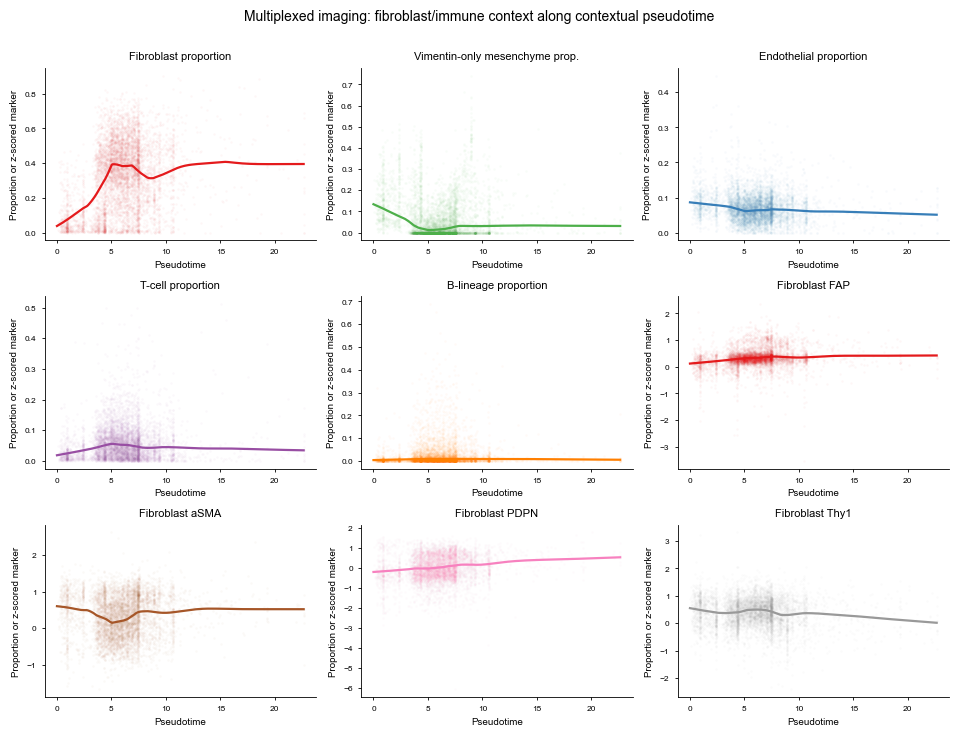

,group,category,feature,label,n,spearman_r,spearman_p,early_q10_median,late_q90_median,late_minus_early_median,mannwhitney_p_early_vs_late
0,Multiplexed imaging: fibroblast/immune context...,composition,surround_prop__Fibroblasts,Fibroblast proportion,46574,0.244996,0.000000e+00,0.052695,0.345972,0.293276,0.000000e+00
5,Multiplexed imaging: fibroblast/immune context...,fibroblast status,surround__Fibroblasts__FAP_expr_z__mean,Fibroblast FAP,46160,0.238489,0.000000e+00,0.161160,0.344742,0.183582,3.812562e-281
7,Multiplexed imaging: fibroblast/immune context...,fibroblast status,surround__Fibroblasts__PDPN_expr_z__mean,Fibroblast PDPN,46160,0.141232,2.969598e-204,-0.235881,0.224245,0.460125,1.439048e-105
4,Multiplexed imaging: fibroblast/immune context...,composition,surround_prop__B_lineage,B-lineage proportion,46574,0.082061,2.093629e-70,0.002626,0.006920,0.004294,5.099742e-89
3,Multiplexed imaging: fibroblast/immune context...,composition,surround_prop__T_cells,T-cell proportion,46574,0.054787,2.660907e-32,0.020543,0.041152,0.020610,3.899717e-122
6,Multiplexed imaging: fibroblast/immune context...,fibroblast status,surround__Fibroblasts__aSMA_expr_z__mean,Fibroblast aSMA,46160,0.046442,1.805083e-23,0.677449,0.512917,-0.164532,5.153866e-21
8,Multiplexed imaging: fibroblast/immune context...,fibroblast status,surround__Fibroblasts__Thy1_expr_z__mean,Fibroblast Thy1,24871,-0.061240,4.186770e-22,0.515390,0.342693,-0.172697,4.775207e-23
1,Multiplexed imaging: fibroblast/immune context...,composition,surround_prop__Vimentin_only_mesenchyme,Vimentin-only mesenchyme prop.,46574,-0.075663,4.224308e-60,0.125915,0.037762,-0.088153,1.486620e-226
2,Multiplexed imaging: fibroblast/immune context...,composition,surround_prop__Endothelial_cells,Endothelial proportion,46574,-0.106317,3.800892e-117,0.081081,0.062500,-0.018581,1.656132e-160


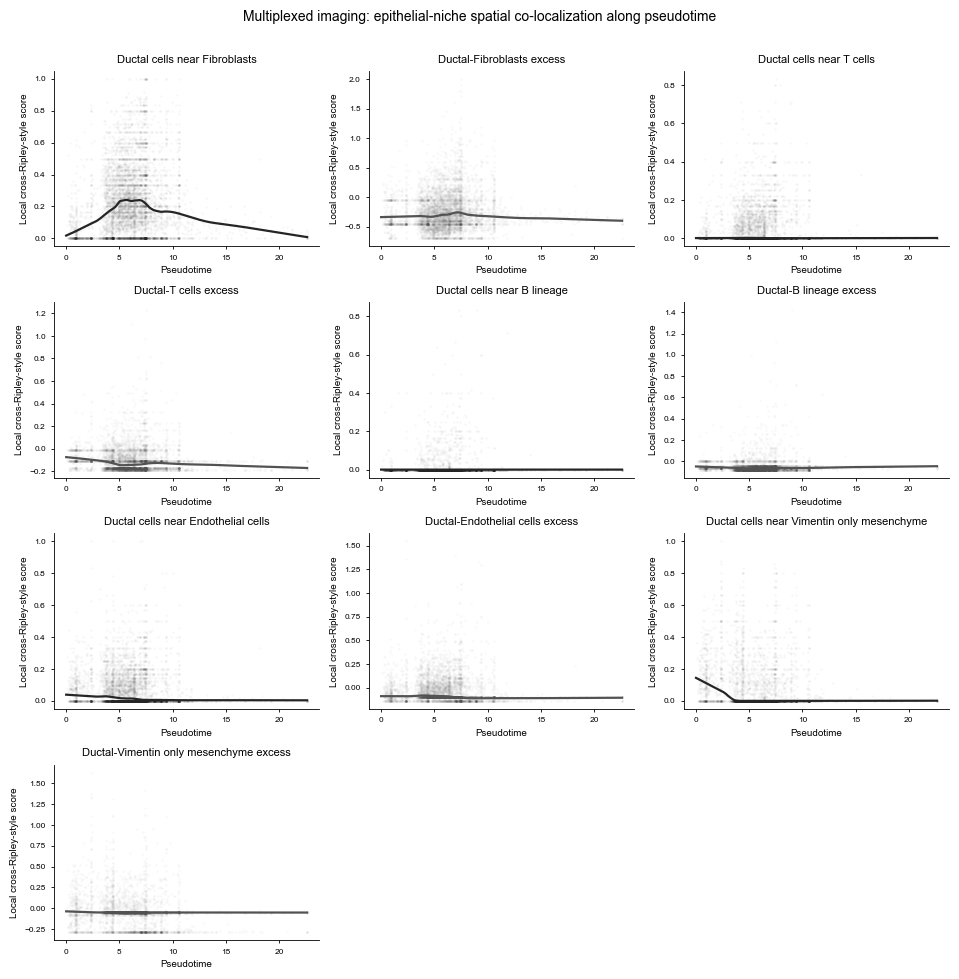

,group,category,feature,label,n,spearman_r,spearman_p,early_q10_median,late_q90_median,late_minus_early_median,mannwhitney_p_early_vs_late
0,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__Fibroblasts__r30__fraction_e...,Ductal cells near Fibroblasts,46574,0.125660,3.205491e-163,0.000000,0.111111,1.111111e-01,1.071978e-230
1,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__Fibroblasts__r30__mean_targe...,Ductal-Fibroblasts excess,46574,0.081275,4.284307e-69,-0.408389,-0.351968,5.642110e-02,5.699880e-08
4,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__B_lineage__r30__fraction_epi...,Ductal cells near B lineage,46574,0.001018,8.261624e-01,0.000000,0.000000,0.000000e+00,1.030085e-06
5,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__B_lineage__r30__mean_target_...,Ductal-B lineage excess,46574,-0.021247,4.526015e-06,-0.061425,-0.061425,0.000000e+00,2.576645e-61
2,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__T_cells__r30__fraction_epith...,Ductal cells near T cells,46574,-0.054917,1.905119e-32,0.000000,0.000000,0.000000e+00,1.510847e-02
3,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__T_cells__r30__mean_target_ne...,Ductal-T cells excess,46574,-0.111935,1.018349e-129,-0.107360,-0.107360,-1.387779e-17,8.137897e-212
9,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__Vimentin_only_mesenchyme__r3...,Ductal-Vimentin only mesenchyme excess,46574,-0.160149,4.018355e-265,-0.053407,-0.053407,-6.938894e-18,1.486288e-48
7,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__Endothelial_cells__r30__mean...,Ductal-Endothelial cells excess,46574,-0.161997,2.626821e-271,-0.091210,-0.102479,-1.126944e-02,3.112276e-59
6,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__Endothelial_cells__r30__frac...,Ductal cells near Endothelial cells,46574,-0.172093,1.995836e-306,0.039216,0.000000,-3.921569e-02,9.970111e-194
8,Multiplexed imaging: epithelial-niche spatial ...,spatial co-localization,coloc__ductal_to__Vimentin_only_mesenchyme__r3...,Ductal cells near Vimentin only mesenchyme,46574,-0.206474,0.000000e+00,0.108402,0.000000,-1.084019e-01,0.000000e+00


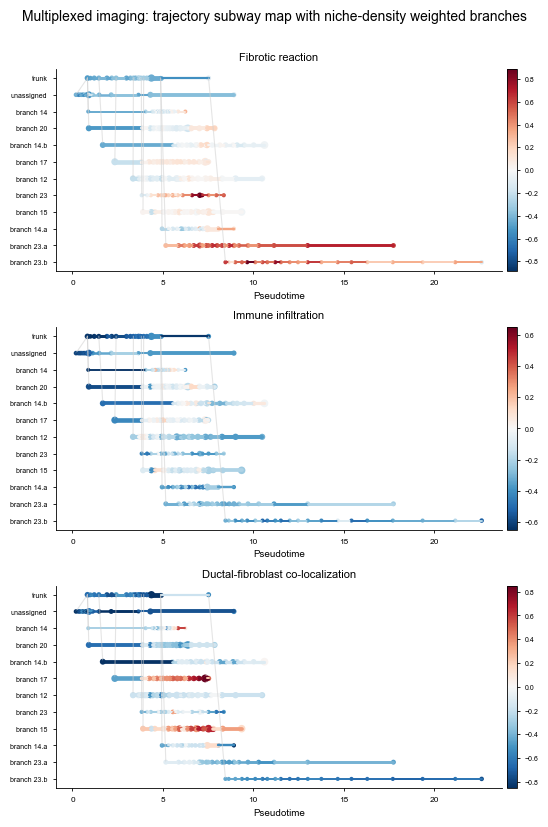

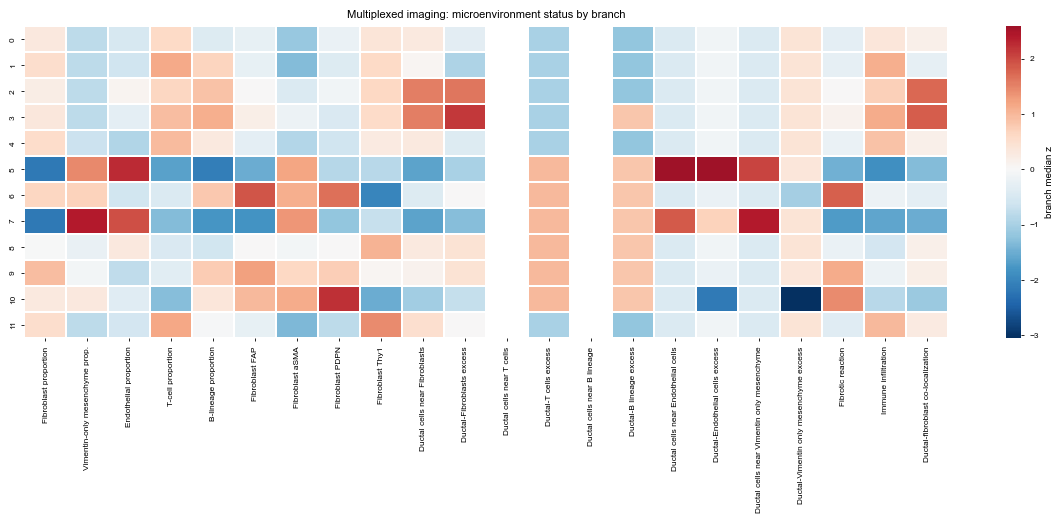

,surround_prop__Fibroblasts,surround_prop__Vimentin_only_mesenchyme,surround_prop__Endothelial_cells,surround_prop__T_cells,surround_prop__B_lineage,surround__Fibroblasts__FAP_expr_z__mean,surround__Fibroblasts__aSMA_expr_z__mean,surround__Fibroblasts__PDPN_expr_z__mean,surround__Fibroblasts__Thy1_expr_z__mean,coloc__ductal_to__Fibroblasts__r30__fraction_epithelial_cells_with_target_neighbor,...,coloc__ductal_to__T_cells__r30__mean_target_neighbor_excess,coloc__ductal_to__B_lineage__r30__fraction_epithelial_cells_with_target_neighbor,coloc__ductal_to__B_lineage__r30__mean_target_neighbor_excess,coloc__ductal_to__Endothelial_cells__r30__fraction_epithelial_cells_with_target_neighbor,coloc__ductal_to__Endothelial_cells__r30__mean_target_neighbor_excess,coloc__ductal_to__Vimentin_only_mesenchyme__r30__fraction_epithelial_cells_with_target_neighbor,coloc__ductal_to__Vimentin_only_mesenchyme__r30__mean_target_neighbor_excess,atlas__fibrotic_reaction,atlas__immune_infiltration,atlas__ductal_fibroblast_colocalization
major_branch,,,,,,,,,,,,,,,,,,,,,
branch 12,0.365617,0.000000,0.063063,0.048170,0.006143,0.311338,0.145337,-0.007889,0.460915,0.200000,...,-0.170721,0.0,-0.078639,0.0,-0.101605,0.0,-0.05132,-0.051533,-0.196340,-0.183172
branch 20,0.391162,0.000000,0.062195,0.054813,0.008081,0.310706,0.101638,-0.055921,0.474005,0.176471,...,-0.170721,0.0,-0.078639,0.0,-0.101605,0.0,-0.05132,-0.044524,-0.091237,-0.326489
branch 15,0.350877,0.000000,0.067640,0.049033,0.008442,0.339040,0.315530,0.013537,0.476162,0.333333,...,-0.170721,0.0,-0.078639,0.0,-0.101605,0.0,-0.05132,0.023290,-0.144410,0.328896
branch 17,0.368227,0.000000,0.064560,0.052506,0.008850,0.360349,0.377731,-0.069362,0.472565,0.333333,...,-0.170721,0.0,-0.061425,0.0,-0.101605,0.0,-0.05132,0.060207,-0.087829,0.356674
branch 14.b,0.391447,0.006579,0.059843,0.052716,0.007364,0.305272,0.208687,-0.103875,0.452504,0.200000,...,-0.170721,0.0,-0.078639,0.0,-0.101605,0.0,-0.05132,-0.030870,-0.123918,-0.183172


PosixPath('/Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/tables/multiplexed_microenvironment_branch_medians.csv')

In [5]:
# ── IMC microenvironment features + spatial co-localisation ──────────────────
# [reason] surround_prop__ features capture cell-type proportions in the 5-hop
# graph neighbourhood; surround__Fibroblasts__FAP_expr_z__mean captures
# fibroblast activation state via protein expression.
MI_MICROENV_FEATURES = [
    {"feature": "surround_prop__Fibroblasts", "label": "Fibroblast proportion", "category": "composition", "color": "#e41a1c"},
    {"feature": "surround_prop__Vimentin_only_mesenchyme", "label": "Vimentin-only mesenchyme prop.", "category": "composition", "color": "#4daf4a"},
    {"feature": "surround_prop__Endothelial_cells", "label": "Endothelial proportion", "category": "composition", "color": "#377eb8"},
    {"feature": "surround_prop__T_cells", "label": "T-cell proportion", "category": "composition", "color": "#984ea3"},
    {"feature": "surround_prop__B_lineage", "label": "B-lineage proportion", "category": "composition", "color": "#ff7f00"},
    {"feature": "surround__Fibroblasts__FAP_expr_z__mean", "label": "Fibroblast FAP", "category": "fibroblast status", "color": "#e41a1c"},
    {"feature": "surround__Fibroblasts__aSMA_expr_z__mean", "label": "Fibroblast aSMA", "category": "fibroblast status", "color": "#a65628"},
    {"feature": "surround__Fibroblasts__PDPN_expr_z__mean", "label": "Fibroblast PDPN", "category": "fibroblast status", "color": "#f781bf"},
    {"feature": "surround__Fibroblasts__Thy1_expr_z__mean", "label": "Fibroblast Thy1", "category": "fibroblast status", "color": "#999999"},
]

MI_COLOC_CACHE = OUTPUT_DIR / "multiplexed_epithelial_niche_local_colocalization.pkl"
FORCE_REBUILD_MI_COLOCALIZATION = False
MI_COLOCALIZATION_RADIUS_UM = 30
MI_COLOCALIZATION_TARGETS = [
    "Fibroblasts",
    "T cells",
    "B lineage",
    "Endothelial cells",
    "Vimentin only mesenchyme",
]

def latest_mi_spatial_cell_paths():
    preferred = sorted(MI_DIR.glob("spatial_cells_auto_branch_n24_v3_with_epithelial_*.pkl"))
    if preferred:
        return preferred
    return sorted(MI_DIR.glob("spatial_cells_*_*.pkl"))

def compute_epithelial_niche_colocalization_for_sample(path, targets, radius_um=30):
    df = pd.read_pickle(path)
    need = [
        "cell_id", "image_id", "sample_id", "x", "y", "Tier_A", MI_KEY,
        "has_pooled_niche", "pooled_pseudotime", "major_branch",
    ]
    keep = [c for c in need if c in df.columns]
    df = df[keep].copy()
    df = df.dropna(subset=["x", "y", "Tier_A"])
    if "has_pooled_niche" in df.columns:
        source = df[df["has_pooled_niche"].fillna(False)].copy()
    else:
        source = df[df[MI_KEY].notna() & ~df[MI_KEY].astype(str).eq("unassigned")].copy()
    source = source[source[MI_KEY].notna() & ~source[MI_KEY].astype(str).eq("unassigned")].copy()
    if source.empty:
        return pd.DataFrame()

    coords_all = df[["x", "y"]].to_numpy(dtype=float)
    x_span = np.nanmax(coords_all[:, 0]) - np.nanmin(coords_all[:, 0])
    y_span = np.nanmax(coords_all[:, 1]) - np.nanmin(coords_all[:, 1])
    window_area = x_span * y_span
    if not np.isfinite(window_area) or window_area <= 0:
        return pd.DataFrame()

    source_coords = source[["x", "y"]].to_numpy(dtype=float)
    meta_cols = [MI_KEY, "image_id", "sample_id", "pooled_pseudotime", "major_branch"]
    source_meta = source[meta_cols].copy()
    rows = []
    for target in targets:
        target_df = df[df["Tier_A"].astype(str).eq(target)].copy()
        if len(target_df) < 5:
            continue
        target_coords = target_df[["x", "y"]].to_numpy(dtype=float)
        tree = BallTree(target_coords)
        neighbors = tree.query_radius(source_coords, r=radius_um)
        counts = np.array([len(nbrs) for nbrs in neighbors], dtype=float)
        expected = (len(target_coords) / window_area) * np.pi * radius_um ** 2
        if expected > 0:
            ratio = counts / expected
        else:
            ratio = np.full_like(counts, np.nan)
        safe_target = safe_label(target)
        tmp = source_meta.copy()
        tmp["_count"] = counts
        tmp["_excess"] = counts - expected
        tmp["_ratio"] = ratio
        tmp["_has_neighbor"] = counts > 0
        agg = (
            tmp.groupby([MI_KEY, "image_id", "sample_id"], observed=True)
            .agg(
                pooled_pseudotime=("pooled_pseudotime", "median"),
                major_branch=("major_branch", lambda s: s.dropna().astype(str).mode().iat[0] if len(s.dropna()) else np.nan),
                n_source_epithelial_cells=("_count", "size"),
                **{
                    f"coloc__ductal_to__{safe_target}__r{radius_um}__mean_target_neighbors_per_epithelial_cell": ("_count", "mean"),
                    f"coloc__ductal_to__{safe_target}__r{radius_um}__mean_target_neighbor_excess": ("_excess", "mean"),
                    f"coloc__ductal_to__{safe_target}__r{radius_um}__mean_target_neighbor_ratio": ("_ratio", "mean"),
                    f"coloc__ductal_to__{safe_target}__r{radius_um}__fraction_epithelial_cells_with_target_neighbor": ("_has_neighbor", "mean"),
                },
            )
            .reset_index()
        )
        rows.append(agg)
    if len(rows) == 0:
        return pd.DataFrame()
    out = rows[0]
    merge_keys = [MI_KEY, "image_id", "sample_id", "pooled_pseudotime", "major_branch", "n_source_epithelial_cells"]
    for extra in rows[1:]:
        out = out.merge(extra, on=merge_keys, how="outer")
    return out

if MI_COLOC_CACHE.exists() and not FORCE_REBUILD_MI_COLOCALIZATION:
    mi_colocalization_df = pd.read_pickle(MI_COLOC_CACHE)
    print(f"Using cached multiplexed co-localization: {MI_COLOC_CACHE}")
else:
    coloc_frames = []
    for path in latest_mi_spatial_cell_paths():
        print(f"Computing epithelial-niche co-localization from {path.name}")
        coloc_frames.append(
            compute_epithelial_niche_colocalization_for_sample(
                path,
                MI_COLOCALIZATION_TARGETS,
                radius_um=MI_COLOCALIZATION_RADIUS_UM,
            )
        )
        gc.collect()
    mi_colocalization_df = pd.concat([f for f in coloc_frames if not f.empty], ignore_index=True)
    save_df(mi_colocalization_df, MI_COLOC_CACHE)

mi_coloc_feature_cols = [
    c for c in mi_colocalization_df.columns
    if c.startswith("coloc__") and (
        c.endswith("__fraction_epithelial_cells_with_target_neighbor")
        or c.endswith("__mean_target_neighbor_excess")
    )
]
mi_context_df = mi_context_df.merge(
    mi_colocalization_df[[MI_KEY, "image_id", "sample_id"] + mi_coloc_feature_cols],
    on=[MI_KEY, "image_id", "sample_id"],
    how="left",
)

MI_COLOCALIZATION_FEATURES = []
for target in MI_COLOCALIZATION_TARGETS:
    safe_target = safe_label(target)
    feature = f"coloc__ductal_to__{safe_target}__r{MI_COLOCALIZATION_RADIUS_UM}__fraction_epithelial_cells_with_target_neighbor"
    if feature in mi_context_df.columns:
        MI_COLOCALIZATION_FEATURES.append({
            "feature": feature,
            "label": f"Ductal cells near {target}",
            "category": "spatial co-localization",
            "color": "#252525",
        })
    excess_feature = f"coloc__ductal_to__{safe_target}__r{MI_COLOCALIZATION_RADIUS_UM}__mean_target_neighbor_excess"
    if excess_feature in mi_context_df.columns:
        MI_COLOCALIZATION_FEATURES.append({
            "feature": excess_feature,
            "label": f"Ductal-{target} excess",
            "category": "spatial co-localization",
            "color": "#525252",
        })

mi_context_df["atlas__fibrotic_reaction"] = zmean(
    mi_context_df,
    [
        "surround_prop__Fibroblasts",
        "surround__Fibroblasts__FAP_expr_z__mean",
        "surround__Fibroblasts__aSMA_expr_z__mean",
        "surround__Fibroblasts__PDPN_expr_z__mean",
    ],
)
mi_context_df["atlas__immune_infiltration"] = zmean(
    mi_context_df,
    ["surround_prop__T_cells", "surround_prop__B_lineage"],
)
mi_context_df["atlas__ductal_fibroblast_colocalization"] = zmean(
    mi_context_df,
    [
        f"coloc__ductal_to__Fibroblasts__r{MI_COLOCALIZATION_RADIUS_UM}__fraction_epithelial_cells_with_target_neighbor",
        f"coloc__ductal_to__Fibroblasts__r{MI_COLOCALIZATION_RADIUS_UM}__mean_target_neighbor_excess",
    ],
)
MI_TREE_FEATURES = [
    {"feature": "atlas__fibrotic_reaction", "label": "Fibrotic reaction", "category": "atlas"},
    {"feature": "atlas__immune_infiltration", "label": "Immune infiltration", "category": "atlas"},
    {"feature": "atlas__ductal_fibroblast_colocalization", "label": "Ductal-fibroblast co-localization", "category": "atlas"},
]

mi_microenv_trend_df = plot_lowess_feature_panel(
    mi_context_df,
    MI_MICROENV_FEATURES,
    pseudotime_col="pooled_pseudotime",
    title="Multiplexed imaging: fibroblast/immune context along contextual pseudotime",
    ylabel="Proportion or z-scored marker",
    n_cols=3,
    save_name="multiplexed_microenvironment_trends_contextual.png",
)
display(mi_microenv_trend_df)
save_df(mi_microenv_trend_df, TABLE_DIR / "multiplexed_microenvironment_trends_contextual.csv")

mi_colocalization_trend_df = plot_lowess_feature_panel(
    mi_context_df,
    MI_COLOCALIZATION_FEATURES,
    pseudotime_col="pooled_pseudotime",
    title="Multiplexed imaging: epithelial-niche spatial co-localization along pseudotime",
    ylabel="Local cross-Ripley-style score",
    n_cols=3,
    save_name="multiplexed_epithelial_niche_colocalization_trends.png",
)
display(mi_colocalization_trend_df)
save_df(mi_colocalization_trend_df, TABLE_DIR / "multiplexed_epithelial_niche_colocalization_trends.csv")

mi_tree_curve_df = plot_trajectory_subway_map_grid(
    mi_context_df,
    branch_col="major_branch",
    pseudotime_col="pooled_pseudotime",
    feature_specs=MI_TREE_FEATURES,
    title_prefix="Multiplexed imaging: trajectory subway map with niche-density weighted branches",
    n_cols=1,
    n_bins=22,
    min_bin_n=18,
    save_name="multiplexed_trajectory_subway_map_key_programs.png",
)
save_df(mi_tree_curve_df, TABLE_DIR / "multiplexed_trajectory_subway_map_key_programs.csv")

mi_branch_microenv_df = plot_branch_heatmap(
    mi_context_df,
    MI_MICROENV_FEATURES + MI_COLOCALIZATION_FEATURES + MI_TREE_FEATURES,
    branch_col="major_branch",
    title="Multiplexed imaging: microenvironment status by branch",
    save_name="multiplexed_microenvironment_branch_heatmap.png",
    top_n=16,
)
display(mi_branch_microenv_df.head())
save_df(mi_branch_microenv_df.reset_index(), TABLE_DIR / "multiplexed_microenvironment_branch_medians.csv")


## Stage 4. IMC: branch-time niche state atlas

Split each trajectory branch into early/mid/late pseudotime thirds and characterise
which microenvironment features define each state. Transition tables highlight the
largest within-branch changes — the specific events (e.g. FAP surge in the invasive
branch at late pseudotime) that are masked by global LOWESS trends.


,dataset,branch,time_bin,branch_time_state,n_niches,pseudotime_median,branch_interpretation,top_enriched_features,top_depleted_features
0,multiplexed imaging,branch 12,early,branch 12 | early,2613,4.013045,branch 12,"T-cell proportion (composition, z=+1.20); Immu...","Fibroblast aSMA (fibroblast status, z=-1.44); ..."
1,multiplexed imaging,branch 12,mid,branch 12 | mid,2613,5.527522,branch 12,"Fibroblast Thy1 (fibroblast status, z=+0.63); ...",Ductal-B lineage excess (spatial co-localizati...
2,multiplexed imaging,branch 12,late,branch 12 | late,2613,7.530825,branch 12,Ductal-B lineage excess (spatial co-localizati...,"B-lineage proportion (composition, z=-0.60); V..."
3,multiplexed imaging,branch 14,early,branch 14 | early,307,4.540613,branch 14,"Fibroblast Thy1 (fibroblast status, z=+1.85); ...",Ductal-B lineage excess (spatial co-localizati...
4,multiplexed imaging,branch 14,mid,branch 14 | mid,306,5.006420,branch 14,"T-cell proportion (composition, z=+1.48); Immu...","Fibroblast aSMA (fibroblast status, z=-1.55); ..."
5,multiplexed imaging,branch 14,late,branch 14 | late,306,5.507196,branch 14,"Immune infiltration (atlas, z=+1.37); T-cell p...",Ductal-B lineage excess (spatial co-localizati...
6,multiplexed imaging,branch 14.a,early,branch 14.a | early,664,5.808062,branch 14.a,"Fibroblast Thy1 (fibroblast status, z=+0.85); ...","B-lineage proportion (composition, z=-1.13); D..."
7,multiplexed imaging,branch 14.a,mid,branch 14.a | mid,663,7.044376,branch 14.a,Ductal-T cells excess (spatial co-localization...,"Immune infiltration (atlas, z=-0.89); T-cell p..."
8,multiplexed imaging,branch 14.a,late,branch 14.a | late,664,7.461982,branch 14.a,Ductal-T cells excess (spatial co-localization...,Ductal cells near Vimentin only mesenchyme (sp...
9,multiplexed imaging,branch 14.b,early,branch 14.b | early,1610,6.114194,branch 14.b,"T-cell proportion (composition, z=+0.95); Immu...",Ductal-B lineage excess (spatial co-localizati...


,dataset,branch,transition,max_abs_delta,max_abs_delta_z,top_changes,top_categories
0,multiplexed imaging,branch 23,branch 23: mid -> late,0.234842,3.225367,Ductal-Vimentin only mesenchyme excess decreas...,"spatial co-localization, fibroblast status, co..."
1,multiplexed imaging,branch 23.a,branch 23.a: mid -> late,0.229465,3.151527,Ductal-Vimentin only mesenchyme excess increas...,"spatial co-localization, composition"
2,multiplexed imaging,branch 23.a,branch 23.a: early -> mid,0.229465,3.151527,Ductal-Vimentin only mesenchyme excess decreas...,"spatial co-localization, fibroblast status, co..."
3,multiplexed imaging,branch 23.b,branch 23.b: mid -> late,0.291668,3.020379,Ductal-Vimentin only mesenchyme excess increas...,"spatial co-localization, fibroblast status, co..."
4,multiplexed imaging,trunk,trunk: mid -> late,0.116690,2.269092,Ductal-Endothelial cells excess decrease (raw ...,"spatial co-localization, fibroblast status, co..."
5,multiplexed imaging,branch 23,branch 23: early -> mid,0.327263,2.098176,"Ductal-T cells excess increase (raw +0.063, z ...","fibroblast status, spatial co-localization, co..."
6,multiplexed imaging,branch 15,branch 15: mid -> late,0.162367,2.098176,"Ductal-T cells excess increase (raw +0.063, z ...","spatial co-localization, fibroblast status, co..."
7,multiplexed imaging,branch 14.a,branch 14.a: early -> mid,0.272365,2.098176,"Ductal-T cells excess increase (raw +0.063, z ...","fibroblast status, spatial co-localization, atlas"
8,multiplexed imaging,unassigned,unassigned: mid -> late,0.180999,2.076743,Ductal cells near Endothelial cells decrease (...,"spatial co-localization, composition, fibrobla..."
9,multiplexed imaging,branch 12,branch 12: mid -> late,0.250099,1.992254,"Ductal-B lineage excess increase (raw +0.017, ...","spatial co-localization, fibroblast status"


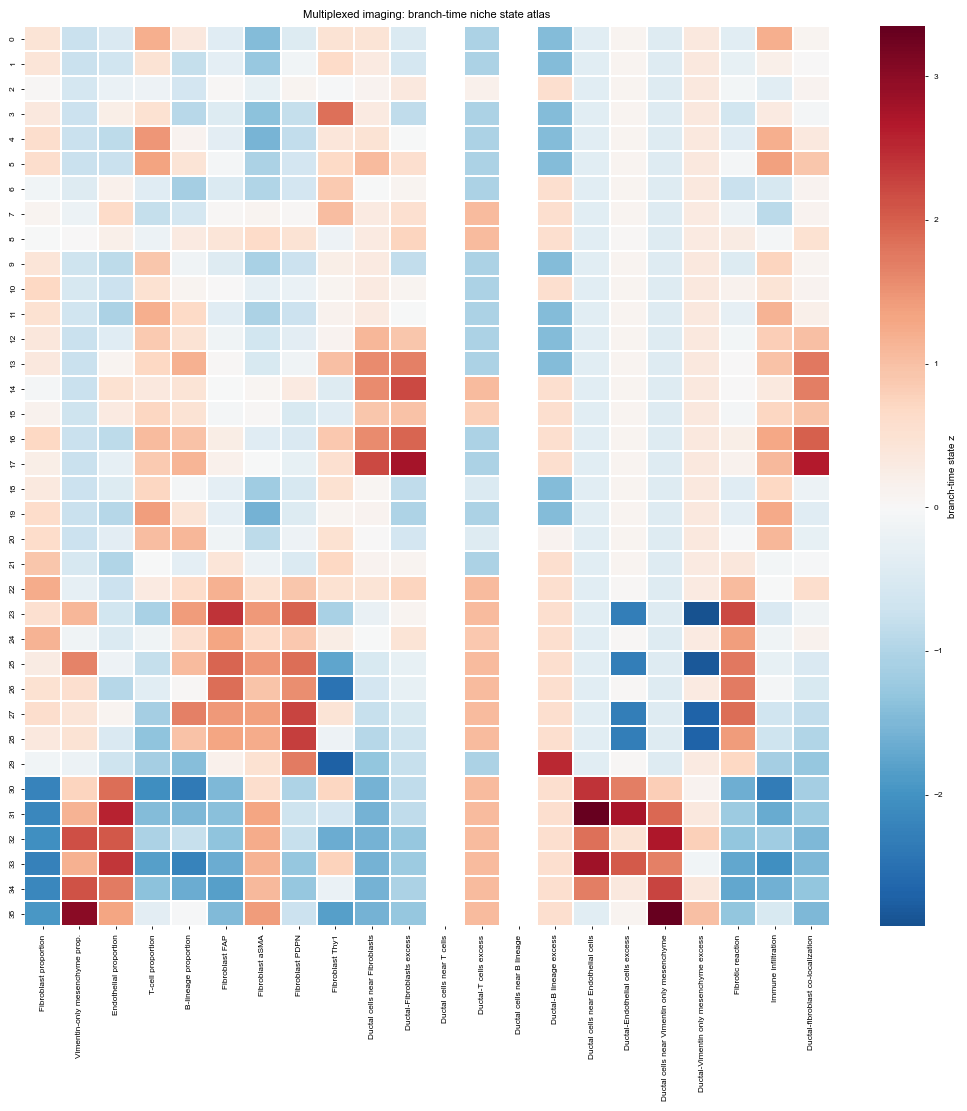

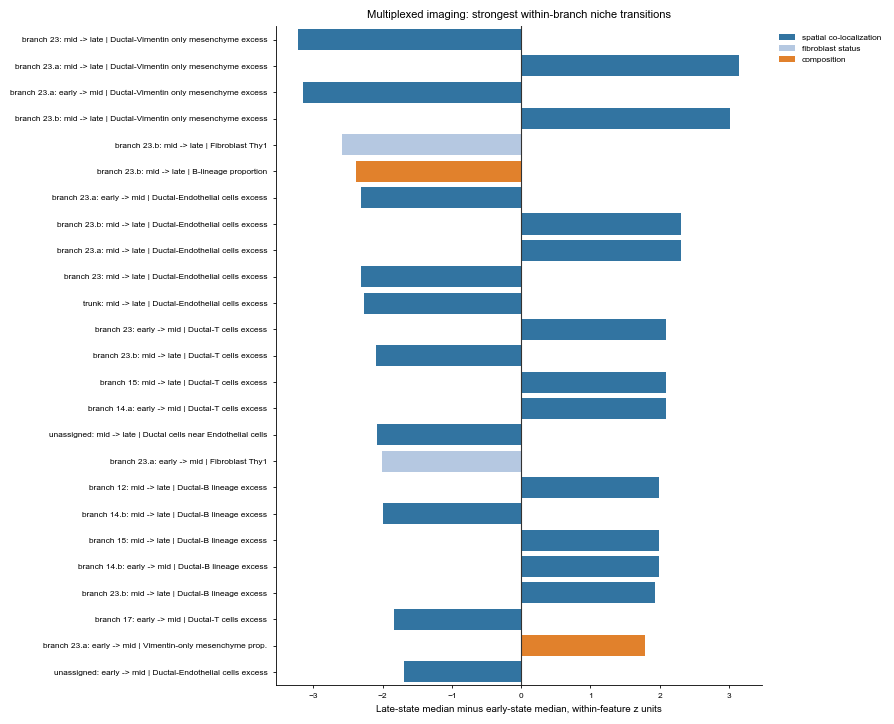

PosixPath('/Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/tables/multiplexed_branch_time_transition_events.csv')

In [6]:
# ── IMC branch-time atlas (early→mid→late per branch) ────────────────────────
# [reason] add_branch_time_bins (sv.tl) splits pseudotime into thirds within
# each branch. state_feature_matrix + summarize_transition_events then identify
# the features that change most dramatically within each state transition.
mi_branch_time_df = add_branch_time_bins(
    mi_context_df,
    branch_col="major_branch",
    pseudotime_col="pooled_pseudotime",
    min_branch_n=45,
)
mi_state_summary_df, mi_state_feature_df = state_feature_matrix(
    mi_branch_time_df,
    MI_MICROENV_FEATURES + MI_COLOCALIZATION_FEATURES + MI_TREE_FEATURES,
    branch_col="major_branch",
    pseudotime_col="pooled_pseudotime",
    dataset_label="multiplexed imaging",
)
mi_state_card_df = build_state_cards(mi_state_feature_df, MI_MICROENV_FEATURES + MI_COLOCALIZATION_FEATURES + MI_TREE_FEATURES, top_n=5)
mi_transition_df = compute_branch_time_transitions(
    mi_state_feature_df,
    MI_MICROENV_FEATURES + MI_COLOCALIZATION_FEATURES + MI_TREE_FEATURES,
    dataset_label="multiplexed imaging",
)
mi_transition_event_df = summarize_transition_events(mi_transition_df, top_n_per_transition=4)

display(mi_state_card_df.head(20))
display(mi_transition_event_df.head(20))

plot_branch_time_state_heatmap(
    mi_state_feature_df,
    MI_MICROENV_FEATURES + MI_COLOCALIZATION_FEATURES + MI_TREE_FEATURES,
    title="Multiplexed imaging: branch-time niche state atlas",
    save_name="multiplexed_branch_time_state_heatmap.png",
)
plot_transition_event_bars(
    mi_transition_df,
    title="Multiplexed imaging: strongest within-branch niche transitions",
    save_name="multiplexed_branch_time_transition_events.png",
    top_n=25,
)

save_df(mi_state_summary_df, TABLE_DIR / "multiplexed_branch_time_state_summary.csv")
save_df(mi_state_card_df, TABLE_DIR / "multiplexed_branch_time_state_cards.csv")
save_df(mi_transition_df, TABLE_DIR / "multiplexed_branch_time_transition_feature_deltas.csv")
save_df(mi_transition_event_df, TABLE_DIR / "multiplexed_branch_time_transition_events.csv")


## Stage 5. Xenium: fibroblast, immune, and myeloid changes along trajectory

Same trend analysis applied to Xenium, where richer gene-level fibroblast and immune
status markers are available (ACTA2, PDGFRA, THY1, DCN for fibroblasts; CD8A, FOXP3,
GZMB, NKG7 for T/NK; CD68, CD163 for myeloid).


,program,n_features,features
0,nbhd_program__fibroblast_activation,9,"surround_prop__Fibroblasts, surround__Fibrobla..."
1,nbhd_program__cytotoxic_t,7,"surround_prop__T_cells, surround__T_cells__CD8..."
2,nbhd_program__treg_checkpoint,2,"surround__T_cells__FOXP3_expr_z__mean, graph_s..."
3,nbhd_program__b_plasma,9,"surround_prop__B_lineage, surround__B_lineage_..."
4,nbhd_program__myeloid_inflammatory,10,"surround_prop__Myeloid_cells, surround__Myeloi..."
5,nbhd_program__endothelial_angiogenic,7,"surround_prop__Endothelial_cells, surround__En..."
6,nbhd_program__neighborhood_mixing,3,"graph_surround__phenotype_entropy, graph_surro..."


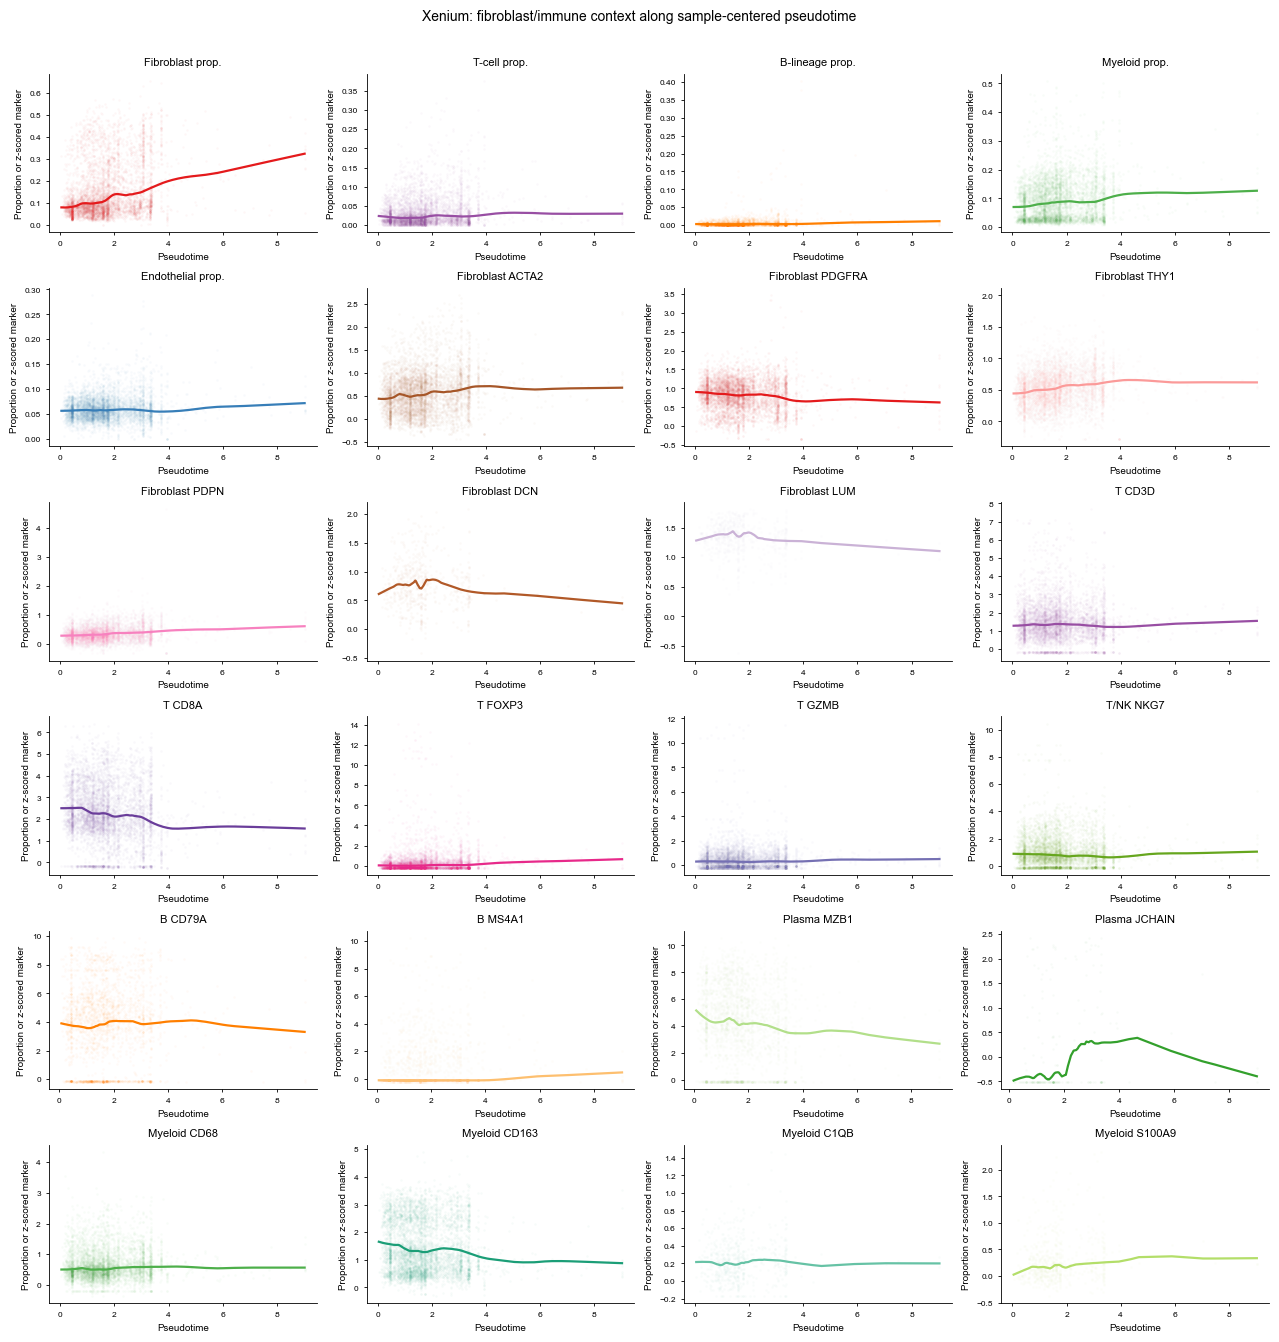

,group,category,feature,label,n,spearman_r,spearman_p,early_q10_median,late_q90_median,late_minus_early_median,mannwhitney_p_early_vs_late
0,Xenium: fibroblast/immune context along sample...,composition,surround_prop__Fibroblasts,Fibroblast prop.,5074,0.279728,7.294248e-92,0.070299,0.176981,0.106682,2.073645e-68
19,Xenium: fibroblast/immune context along sample...,B-lineage status,surround__B_lineage__JCHAIN_expr_z__mean,Plasma JCHAIN,188,0.220818,2.325274e-03,-0.507173,-0.147147,0.360026,3.485879e-02
7,Xenium: fibroblast/immune context along sample...,fibroblast status,surround__Fibroblasts__THY1_expr_z__mean,Fibroblast THY1,4486,0.177428,4.775845e-33,0.436339,0.594234,0.157896,3.518304e-20
8,Xenium: fibroblast/immune context along sample...,fibroblast status,surround__Fibroblasts__PDPN_expr_z__mean,Fibroblast PDPN,4486,0.177037,6.594336e-33,0.291724,0.431002,0.139277,6.388991e-16
5,Xenium: fibroblast/immune context along sample...,fibroblast status,surround__Fibroblasts__ACTA2_expr_z__mean,Fibroblast ACTA2,5071,0.154345,2.081414e-28,0.379227,0.680640,0.301413,5.669607e-27
23,Xenium: fibroblast/immune context along sample...,myeloid status,surround__Myeloid_cells__S100A9_expr_z__mean,Myeloid S100A9,587,0.132850,1.254721e-03,0.065727,0.248981,0.183254,1.661546e-02
13,Xenium: fibroblast/immune context along sample...,T-cell status,surround__T_cells__FOXP3_expr_z__mean,T FOXP3,4877,0.124599,2.473848e-18,-0.103648,0.154470,0.258119,7.930237e-12
2,Xenium: fibroblast/immune context along sample...,composition,surround_prop__B_lineage,B-lineage prop.,3297,0.123574,1.077700e-12,0.001963,0.002656,0.000693,7.799994e-03
3,Xenium: fibroblast/immune context along sample...,composition,surround_prop__Myeloid_cells,Myeloid prop.,5074,0.120773,6.007654e-18,0.060495,0.097826,0.037331,4.352172e-17
1,Xenium: fibroblast/immune context along sample...,composition,surround_prop__T_cells,T-cell prop.,5074,0.106274,3.205727e-14,0.017202,0.022568,0.005367,8.985347e-05


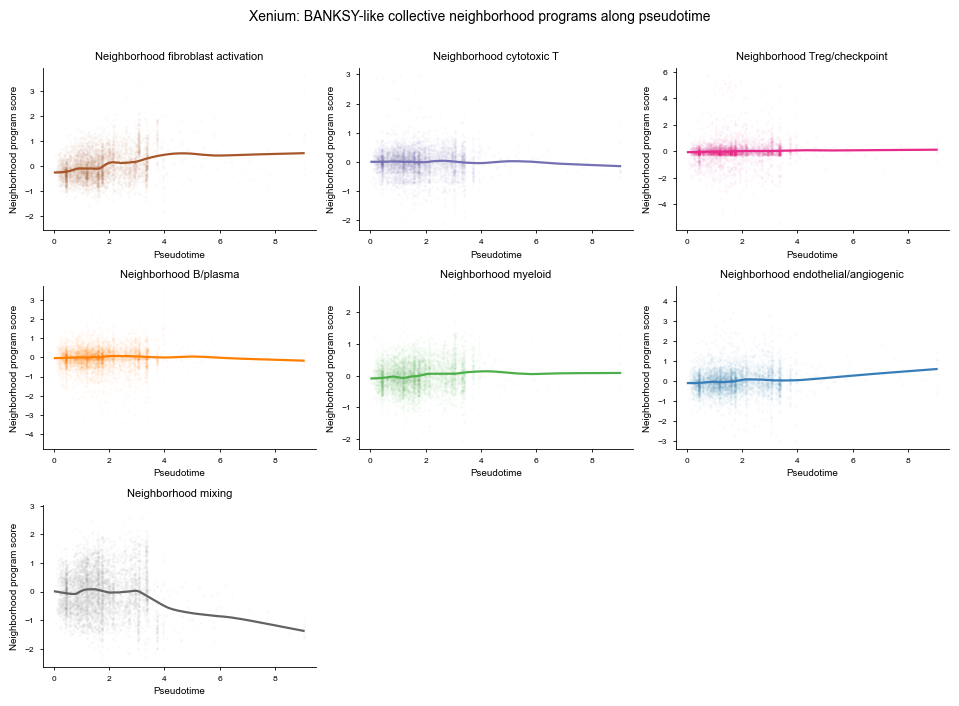

,group,category,feature,label,n,spearman_r,spearman_p,early_q10_median,late_q90_median,late_minus_early_median,mannwhitney_p_early_vs_late
0,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__fibroblast_activation,Neighborhood fibroblast activation,5074,0.282865,5.589856e-94,-0.264942,0.291033,0.555976,3.418089e-63
4,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__myeloid_inflammatory,Neighborhood myeloid,5074,0.124580,5.260382e-19,-0.089722,0.076214,0.165935,4.102027e-14
2,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__treg_checkpoint,Neighborhood Treg/checkpoint,5074,0.114836,2.303340e-16,-0.075939,0.021234,0.097173,2.895986e-14
5,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__endothelial_angiogenic,Neighborhood endothelial/angiogenic,5074,0.104888,6.876672e-14,-0.113253,0.057407,0.170659,1.082555e-10
3,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__b_plasma,Neighborhood B/plasma,5074,0.054717,9.636594e-05,-0.037903,0.018870,0.056773,7.573386e-03
1,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__cytotoxic_t,Neighborhood cytotoxic T,5074,-0.007090,6.136039e-01,-0.004562,0.009115,0.013677,8.079375e-01
6,Xenium: BANKSY-like collective neighborhood pr...,neighborhood program,nbhd_program__neighborhood_mixing,Neighborhood mixing,5074,-0.017459,2.137128e-01,-0.014733,-0.084350,-0.069617,1.976889e-01


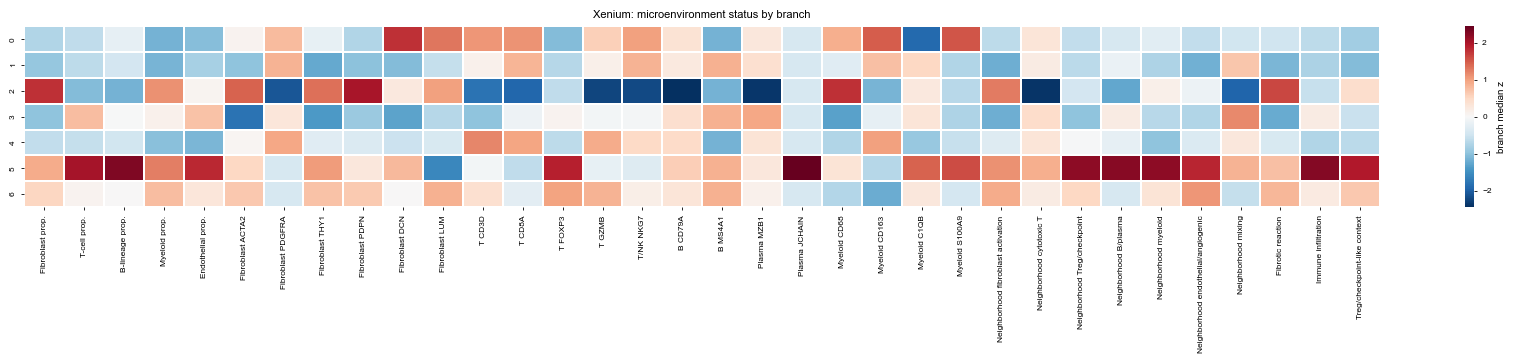

,surround_prop__Fibroblasts,surround_prop__T_cells,surround_prop__B_lineage,surround_prop__Myeloid_cells,surround_prop__Endothelial_cells,surround__Fibroblasts__ACTA2_expr_z__mean,surround__Fibroblasts__PDGFRA_expr_z__mean,surround__Fibroblasts__THY1_expr_z__mean,surround__Fibroblasts__PDPN_expr_z__mean,surround__Fibroblasts__DCN_expr_z__mean,...,nbhd_program__fibroblast_activation,nbhd_program__cytotoxic_t,nbhd_program__treg_checkpoint,nbhd_program__b_plasma,nbhd_program__myeloid_inflammatory,nbhd_program__endothelial_angiogenic,nbhd_program__neighborhood_mixing,atlas__fibrotic_reaction,atlas__immune_infiltration,atlas__immune_suppression_checkpoint
major_branch,,,,,,,,,,,,,,,,,,,,,
trunk,0.089083,0.015072,0.002320,0.035292,0.052368,0.556434,0.951176,0.548061,0.312374,1.233513,...,-0.140701,0.042248,-0.046830,-0.011876,-0.029648,-0.047852,-0.280382,-0.130049,-0.160552,-0.198276
other,0.067854,0.014223,0.001781,0.036145,0.054234,0.400102,0.969146,0.422053,0.280828,0.400623,...,-0.321254,0.025963,-0.050150,0.012240,-0.098919,-0.124892,0.214781,-0.445628,-0.204262,-0.220846
branch 3,0.348703,0.004260,0.000000,0.150768,0.061757,0.756244,0.252536,0.735085,0.623773,0.787379,...,0.495750,-0.354436,-0.037686,-0.092457,0.029118,0.013242,-0.920371,0.946164,-0.135226,-0.051414
branch 2,0.064293,0.047425,0.002845,0.100216,0.067158,0.276835,0.832734,0.403624,0.292716,0.327908,...,-0.325217,0.063510,-0.068041,0.046773,-0.088100,-0.066609,0.432741,-0.500640,0.101185,-0.162074
branch 4,0.103491,0.015714,0.001705,0.041958,0.051635,0.551367,0.994425,0.535493,0.355725,0.557280,...,-0.031527,0.043914,-0.013934,0.006704,-0.130054,-0.015305,0.043707,-0.081063,-0.190223,-0.175105


PosixPath('/Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/tables/xenium_microenvironment_branch_medians.csv')

In [7]:
# ── Xenium microenvironment features (composition + cell-type status) ─────────
# [reason] Xenium provides transcript-level fibroblast subtype markers not
# available in IMC, enabling finer-grained CAF classification along pseudotime.
XENIUM_MICROENV_FEATURES = [
    {"feature": "surround_prop__Fibroblasts", "label": "Fibroblast prop.", "category": "composition", "color": "#e41a1c"},
    {"feature": "surround_prop__T_cells", "label": "T-cell prop.", "category": "composition", "color": "#984ea3"},
    {"feature": "surround_prop__B_lineage", "label": "B-lineage prop.", "category": "composition", "color": "#ff7f00"},
    {"feature": "surround_prop__Myeloid_cells", "label": "Myeloid prop.", "category": "composition", "color": "#4daf4a"},
    {"feature": "surround_prop__Endothelial_cells", "label": "Endothelial prop.", "category": "composition", "color": "#377eb8"},
    {"feature": "surround__Fibroblasts__ACTA2_expr_z__mean", "label": "Fibroblast ACTA2", "category": "fibroblast status", "color": "#a65628"},
    {"feature": "surround__Fibroblasts__PDGFRA_expr_z__mean", "label": "Fibroblast PDGFRA", "category": "fibroblast status", "color": "#e41a1c"},
    {"feature": "surround__Fibroblasts__THY1_expr_z__mean", "label": "Fibroblast THY1", "category": "fibroblast status", "color": "#fb9a99"},
    {"feature": "surround__Fibroblasts__PDPN_expr_z__mean", "label": "Fibroblast PDPN", "category": "fibroblast status", "color": "#f781bf"},
    {"feature": "surround__Fibroblasts__DCN_expr_z__mean", "label": "Fibroblast DCN", "category": "fibroblast status", "color": "#b15928"},
    {"feature": "surround__Fibroblasts__LUM_expr_z__mean", "label": "Fibroblast LUM", "category": "fibroblast status", "color": "#cab2d6"},
    {"feature": "surround__T_cells__CD3D_expr_z__mean", "label": "T CD3D", "category": "T-cell status", "color": "#984ea3"},
    {"feature": "surround__T_cells__CD8A_expr_z__mean", "label": "T CD8A", "category": "T-cell status", "color": "#6a3d9a"},
    {"feature": "surround__T_cells__FOXP3_expr_z__mean", "label": "T FOXP3", "category": "T-cell status", "color": "#e7298a"},
    {"feature": "surround__T_cells__GZMB_expr_z__mean", "label": "T GZMB", "category": "T-cell status", "color": "#7570b3"},
    {"feature": "surround__T_cells__NKG7_expr_z__mean", "label": "T/NK NKG7", "category": "T-cell status", "color": "#66a61e"},
    {"feature": "surround__B_lineage__CD79A_expr_z__mean", "label": "B CD79A", "category": "B-lineage status", "color": "#ff7f00"},
    {"feature": "surround__B_lineage__MS4A1_expr_z__mean", "label": "B MS4A1", "category": "B-lineage status", "color": "#fdbf6f"},
    {"feature": "surround__B_lineage__MZB1_expr_z__mean", "label": "Plasma MZB1", "category": "B-lineage status", "color": "#b2df8a"},
    {"feature": "surround__B_lineage__JCHAIN_expr_z__mean", "label": "Plasma JCHAIN", "category": "B-lineage status", "color": "#33a02c"},
    {"feature": "surround__Myeloid_cells__CD68_expr_z__mean", "label": "Myeloid CD68", "category": "myeloid status", "color": "#4daf4a"},
    {"feature": "surround__Myeloid_cells__CD163_expr_z__mean", "label": "Myeloid CD163", "category": "myeloid status", "color": "#1b9e77"},
    {"feature": "surround__Myeloid_cells__C1QB_expr_z__mean", "label": "Myeloid C1QB", "category": "myeloid status", "color": "#66c2a5"},
    {"feature": "surround__Myeloid_cells__S100A9_expr_z__mean", "label": "Myeloid S100A9", "category": "myeloid status", "color": "#b3de69"},
]

def add_xenium_neighborhood_program_scores(df):
    df = df.copy()
    program_defs = {
        "nbhd_program__fibroblast_activation": [
            "surround_prop__Fibroblasts",
            "surround__Fibroblasts__ACTA2_expr_z__mean",
            "surround__Fibroblasts__THY1_expr_z__mean",
            "surround__Fibroblasts__PDPN_expr_z__mean",
            "surround__Fibroblasts__DCN_expr_z__mean",
            "surround__Fibroblasts__LUM_expr_z__mean",
            "graph_surround__ACTA2_expr_z__surround_minus_niche",
            "graph_surround__PDPN_expr_z__surround_minus_niche",
            "graph_surround__PDGFRA_expr_z__surround_minus_niche",
        ],
        "nbhd_program__cytotoxic_t": [
            "surround_prop__T_cells",
            "surround__T_cells__CD8A_expr_z__mean",
            "surround__T_cells__GZMB_expr_z__mean",
            "surround__T_cells__NKG7_expr_z__mean",
            "graph_surround__CD8A_expr_z__surround_minus_niche",
            "graph_surround__GZMB_expr_z__surround_minus_niche",
            "graph_surround__NKG7_expr_z__surround_minus_niche",
        ],
        "nbhd_program__treg_checkpoint": [
            "surround__T_cells__FOXP3_expr_z__mean",
            "graph_surround__FOXP3_expr_z__surround_minus_niche",
            "graph_surround__PDCD1_expr_z__surround_minus_niche",
            "graph_surround__CD274_expr_z__surround_minus_niche",
        ],
        "nbhd_program__b_plasma": [
            "surround_prop__B_lineage",
            "surround__B_lineage__CD79A_expr_z__mean",
            "surround__B_lineage__MS4A1_expr_z__mean",
            "surround__B_lineage__MZB1_expr_z__mean",
            "surround__B_lineage__JCHAIN_expr_z__mean",
            "graph_surround__CD79A_expr_z__surround_minus_niche",
            "graph_surround__MS4A1_expr_z__surround_minus_niche",
            "graph_surround__MZB1_expr_z__surround_minus_niche",
            "graph_surround__JCHAIN_expr_z__surround_minus_niche",
        ],
        "nbhd_program__myeloid_inflammatory": [
            "surround_prop__Myeloid_cells",
            "surround__Myeloid_cells__CD68_expr_z__mean",
            "surround__Myeloid_cells__CD163_expr_z__mean",
            "surround__Myeloid_cells__C1QB_expr_z__mean",
            "surround__Myeloid_cells__S100A9_expr_z__mean",
            "graph_surround__CD68_expr_z__surround_minus_niche",
            "graph_surround__CD163_expr_z__surround_minus_niche",
            "graph_surround__C1QB_expr_z__surround_minus_niche",
            "graph_surround__S100A9_expr_z__surround_minus_niche",
            "graph_surround__AIF1_expr_z__surround_minus_niche",
        ],
        "nbhd_program__endothelial_angiogenic": [
            "surround_prop__Endothelial_cells",
            "surround__Endothelial_cells__PECAM1_expr_z__mean",
            "surround__Endothelial_cells__CD34_expr_z__mean",
            "graph_surround__PECAM1_expr_z__surround_minus_niche",
            "graph_surround__CD34_expr_z__surround_minus_niche",
            "graph_surround__VWF_expr_z__surround_minus_niche",
            "graph_surround__FLT1_expr_z__surround_minus_niche",
        ],
        "nbhd_program__neighborhood_mixing": [
            "graph_surround__phenotype_entropy",
            "graph_surround__cross_edges_per_niche_cell",
            "graph_surround__surround_to_niche_ratio",
        ],
    }
    availability_rows = []
    for program, cols in program_defs.items():
        present = [c for c in cols if c in df.columns]
        df[program] = zmean(df, present)
        availability_rows.append({
            "program": program,
            "n_features": len(present),
            "features": ", ".join(present),
        })
    return df, pd.DataFrame(availability_rows)

xenium_context_df, xenium_neighborhood_program_availability_df = add_xenium_neighborhood_program_scores(xenium_context_df)
display(xenium_neighborhood_program_availability_df)
save_df(xenium_neighborhood_program_availability_df, TABLE_DIR / "xenium_neighborhood_program_availability.csv")

XENIUM_NEIGHBORHOOD_PROGRAM_FEATURES = [
    {"feature": "nbhd_program__fibroblast_activation", "label": "Neighborhood fibroblast activation", "category": "neighborhood program", "color": "#a65628"},
    {"feature": "nbhd_program__cytotoxic_t", "label": "Neighborhood cytotoxic T", "category": "neighborhood program", "color": "#7570b3"},
    {"feature": "nbhd_program__treg_checkpoint", "label": "Neighborhood Treg/checkpoint", "category": "neighborhood program", "color": "#e7298a"},
    {"feature": "nbhd_program__b_plasma", "label": "Neighborhood B/plasma", "category": "neighborhood program", "color": "#ff7f00"},
    {"feature": "nbhd_program__myeloid_inflammatory", "label": "Neighborhood myeloid", "category": "neighborhood program", "color": "#4daf4a"},
    {"feature": "nbhd_program__endothelial_angiogenic", "label": "Neighborhood endothelial/angiogenic", "category": "neighborhood program", "color": "#377eb8"},
    {"feature": "nbhd_program__neighborhood_mixing", "label": "Neighborhood mixing", "category": "neighborhood program", "color": "#636363"},
]

xenium_context_df["atlas__fibrotic_reaction"] = zmean(
    xenium_context_df,
    [
        "surround_prop__Fibroblasts",
        "surround__Fibroblasts__ACTA2_expr_z__mean",
        "surround__Fibroblasts__THY1_expr_z__mean",
        "surround__Fibroblasts__PDPN_expr_z__mean",
        "nbhd_program__fibroblast_activation",
    ],
)
xenium_context_df["atlas__immune_infiltration"] = zmean(
    xenium_context_df,
    [
        "surround_prop__T_cells",
        "surround_prop__B_lineage",
        "surround_prop__Myeloid_cells",
        "nbhd_program__cytotoxic_t",
        "nbhd_program__b_plasma",
        "nbhd_program__myeloid_inflammatory",
    ],
)
xenium_context_df["atlas__immune_suppression_checkpoint"] = zmean(
    xenium_context_df,
    [
        "surround__T_cells__FOXP3_expr_z__mean",
        "nbhd_program__treg_checkpoint",
    ],
)
XENIUM_TREE_FEATURES = [
    {"feature": "atlas__fibrotic_reaction", "label": "Fibrotic reaction", "category": "atlas"},
    {"feature": "atlas__immune_infiltration", "label": "Immune infiltration", "category": "atlas"},
    {"feature": "atlas__immune_suppression_checkpoint", "label": "Treg/checkpoint-like context", "category": "atlas"},
    {"feature": "nbhd_program__endothelial_angiogenic", "label": "Endothelial/angiogenic neighborhood", "category": "neighborhood program"},
]

xenium_microenv_trend_df = plot_lowess_feature_panel(
    xenium_context_df,
    XENIUM_MICROENV_FEATURES,
    pseudotime_col="xenium_pseudotime_sample_centered",
    title="Xenium: fibroblast/immune context along sample-centered pseudotime",
    ylabel="Proportion or z-scored marker",
    n_cols=4,
    figsize_scale=2.2,
    save_name="xenium_microenvironment_trends_sample_centered.png",
)
display(xenium_microenv_trend_df)
save_df(xenium_microenv_trend_df, TABLE_DIR / "xenium_microenvironment_trends_sample_centered.csv")

xenium_neighborhood_program_trend_df = plot_lowess_feature_panel(
    xenium_context_df,
    XENIUM_NEIGHBORHOOD_PROGRAM_FEATURES,
    pseudotime_col="xenium_pseudotime_sample_centered",
    title="Xenium: BANKSY-like collective neighborhood programs along pseudotime",
    ylabel="Neighborhood program score",
    n_cols=3,
    figsize_scale=2.3,
    save_name="xenium_neighborhood_program_trends_sample_centered.png",
)
display(xenium_neighborhood_program_trend_df)
save_df(xenium_neighborhood_program_trend_df, TABLE_DIR / "xenium_neighborhood_program_trends_sample_centered.csv")

xenium_branch_microenv_df = plot_branch_heatmap(
    xenium_context_df,
    XENIUM_MICROENV_FEATURES + XENIUM_NEIGHBORHOOD_PROGRAM_FEATURES + XENIUM_TREE_FEATURES,
    branch_col="major_branch",
    title="Xenium: microenvironment status by branch",
    save_name="xenium_microenvironment_branch_heatmap.png",
)
display(xenium_branch_microenv_df.head())
save_df(xenium_branch_microenv_df.reset_index(), TABLE_DIR / "xenium_microenvironment_branch_medians.csv")


## Stage 6. Xenium: targeted ligand-receptor communication potential

For each ductal niche, compute a product score: mean ligand expression in source cell type ×
mean receptor expression in target cell type (from the surround context). Weighted by the
proportion of the target cell type in the niche's local graph neighbourhood.

**Key pairs tested (biological rationale):**
- Fibroblast CXCL12 → epithelial CXCR4: stromal chemoattraction / CAF-tumour axis
- Epithelial AREG → epithelial EGFR: autocrine EGFR proliferation signal
- Epithelial CSF1 → myeloid CSF1R: tumour-driven macrophage recruitment
- Epithelial CCL2 → myeloid CCR2: monocyte recruitment
- Epithelial VEGFA → endothelial FLT1: tumour-driven angiogenesis
- Epithelial CD274 → T-cell PDCD1: tumour immune checkpoint suppression

This is a **lightweight spatial CCC proxy** — the product scores are candidates for
validation, not proof of signalling (following the NicheNet/CCC spirit).


In [8]:
# ── Build Xenium LR context (per-niche mean ligand × receptor scores) ─────────
# [reason] For each niche, mean gene expression per cell type is extracted from
# the _with_niches.h5ad, then multiplied to form the LR product score.
LR_CACHE = OUTPUT_DIR / "xenium_targeted_lr_context_log1p_nonnegative.pkl"
FORCE_REBUILD_LR_CONTEXT = False

XENIUM_SAMPLE_CONFIGS = [
    {"sample_id": "pdac_pancreas_v1"},
    {"sample_id": "pdac_io_v1"},
    {"sample_id": "pdac_addon_v1"},
    {"sample_id": "normal_nondiseased_v1"},
]

CANDIDATE_LR_PAIRS = [
    {"source": "Fibroblasts", "target": "pancreatic ductal epithelium", "ligand": "CXCL12", "receptor": "CXCR4", "label": "Fibroblast CXCL12 -> epithelial CXCR4"},
    {"source": "pancreatic ductal epithelium", "target": "pancreatic ductal epithelium", "ligand": "AREG", "receptor": "EGFR", "label": "Epithelial AREG -> epithelial EGFR"},
    {"source": "pancreatic ductal epithelium", "target": "Myeloid cells", "ligand": "CSF1", "receptor": "CSF1R", "label": "Epithelial CSF1 -> myeloid CSF1R"},
    {"source": "pancreatic ductal epithelium", "target": "Myeloid cells", "ligand": "CCL2", "receptor": "CCR2", "label": "Epithelial CCL2 -> myeloid CCR2"},
    {"source": "pancreatic ductal epithelium", "target": "Endothelial cells", "ligand": "VEGFA", "receptor": "FLT1", "label": "Epithelial VEGFA -> endothelial FLT1"},
    {"source": "pancreatic ductal epithelium", "target": "T cells", "ligand": "CD274", "receptor": "PDCD1", "label": "Epithelial CD274 -> T-cell PDCD1"},
    {"source": "Myeloid cells", "target": "T cells", "ligand": "CD274", "receptor": "PDCD1", "label": "Myeloid CD274 -> T-cell PDCD1"},
    {"source": "pancreatic ductal epithelium", "target": "B lineage", "ligand": "MIF", "receptor": "CD74", "label": "Epithelial MIF -> B-lineage CD74"},
]

LR_GENES = sorted(set([p["ligand"] for p in CANDIDATE_LR_PAIRS] + [p["receptor"] for p in CANDIDATE_LR_PAIRS]))
LR_PHENOTYPES = sorted(set([p["source"] for p in CANDIDATE_LR_PAIRS] + [p["target"] for p in CANDIDATE_LR_PAIRS] + ["T cells", "B lineage", "Myeloid cells", "Fibroblasts", "Endothelial cells"]))

def extract_gene_matrix(adata, genes):
    present = [g for g in genes if g in adata.var_names]
    if len(present) == 0:
        return pd.DataFrame(index=adata.obs_names)
    if "log1p" in adata.layers:
        X = adata[:, present].layers["log1p"]
    elif "counts" in adata.layers:
        X = adata[:, present].layers["counts"]
    else:
        X = adata[:, present].X
    if sparse.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=float)
    X = np.clip(X, 0, None)
    return pd.DataFrame(X, index=adata.obs_names.astype(str), columns=present)

def add_lr_gene_obs_columns(adata, genes):
    expr = extract_gene_matrix(adata, genes)
    for gene in expr.columns:
        vals = pd.to_numeric(expr[gene], errors="coerce")
        adata.obs[f"{gene}_lr_expr"] = vals.to_numpy()
    return list(expr.columns)

def summarize_lr_context_for_sample(sample_id):
    adata_path = XENIUM_NICHE_DIR / f"{sample_id}_with_niches.h5ad"
    if not adata_path.exists():
        print(f"Missing {adata_path}")
        return pd.DataFrame()
    adata = sc.read_h5ad(adata_path)
    present_genes = add_lr_gene_obs_columns(adata, LR_GENES)
    if len(present_genes) == 0:
        return pd.DataFrame()

    source_mask = (
        adata.obs[XENIUM_KEY].notna()
        & (adata.obs["Tier_A"].astype(str) == "pancreatic ductal epithelium")
    )
    source_cols = [f"{g}_lr_expr" for g in present_genes]
    source_df = (
        adata.obs.loc[source_mask, [XENIUM_KEY] + source_cols]
        .groupby(XENIUM_KEY, observed=True)[source_cols]
        .mean()
        .reset_index()
    )
    source_df = source_df.rename(columns={c: f"source__pancreatic_ductal_epithelium__{c}__mean" for c in source_cols})

    phenotype_labels = [
        label
        for label in LR_PHENOTYPES
        if label in set(adata.obs["Tier_A"].dropna().astype(str))
    ]
    phenotype_feature_map = {label: source_cols for label in phenotype_labels}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        context_df = sv.summarize_niche_surrounding_context(
            adata,
            niche_key=XENIUM_KEY,
            phenotype_key="Tier_A",
            phenotype_labels=phenotype_labels,
            phenotype_feature_map=phenotype_feature_map,
            image_key="sample_id",
            adjacency_key="cell_graph_connectivities",
            surround_hops=5,
            min_cells=5,
            summary_stats=("mean",),
            show_progress=True,
            progress_desc=f"{sample_id} LR surroundings",
        )
    out = source_df.merge(context_df.drop(columns=["n_cells"], errors="ignore"), on=XENIUM_KEY, how="left")
    out["sample_id"] = sample_id
    out["lr_genes_present"] = ",".join(present_genes)
    del adata
    gc.collect()
    return out

if LR_CACHE.exists() and not FORCE_REBUILD_LR_CONTEXT:
    xenium_lr_context_df = pd.read_pickle(LR_CACHE)
    print(f"Using cached LR context: {LR_CACHE}")
else:
    frames = []
    for cfg in XENIUM_SAMPLE_CONFIGS:
        frames.append(summarize_lr_context_for_sample(cfg["sample_id"]))
    xenium_lr_context_df = pd.concat([f for f in frames if not f.empty], ignore_index=True)
    save_df(xenium_lr_context_df, LR_CACHE)

print(xenium_lr_context_df.shape)
xenium_lr_context_df.head()


Using cached LR context: /Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/xenium_targeted_lr_context_log1p_nonnegative.pkl
(5074, 191)


,xenium_ductal_epithelium_component,source__pancreatic_ductal_epithelium__CCR2_lr_expr__mean,source__pancreatic_ductal_epithelium__CD274_lr_expr__mean,source__pancreatic_ductal_epithelium__CXCR4_lr_expr__mean,source__pancreatic_ductal_epithelium__EGFR_lr_expr__mean,source__pancreatic_ductal_epithelium__PDCD1_lr_expr__mean,image_id,n_surround,surround__hop_1__n_cells,surround__hop_2__n_cells,...,surround__pancreatic_ductal_epithelium__CSF1_lr_expr__n_cells,surround__pancreatic_ductal_epithelium__CSF1_lr_expr__mean,surround__pancreatic_ductal_epithelium__CSF1R_lr_expr__n_cells,surround__pancreatic_ductal_epithelium__CSF1R_lr_expr__mean,surround__pancreatic_ductal_epithelium__CXCL12_lr_expr__n_cells,surround__pancreatic_ductal_epithelium__CXCL12_lr_expr__mean,surround__pancreatic_ductal_epithelium__FLT1_lr_expr__n_cells,surround__pancreatic_ductal_epithelium__FLT1_lr_expr__mean,surround__pancreatic_ductal_epithelium__VEGFA_lr_expr__n_cells,surround__pancreatic_ductal_epithelium__VEGFA_lr_expr__mean
0,pdac_pancreas_v1__ductal_boundary_00001,0.000000,0.0,0.832935,1.698030,0.000000,pdac_pancreas_v1,287.0,20.0,48.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pdac_pancreas_v1__ductal_boundary_00002,0.032835,0.0,0.177459,2.329282,0.000000,pdac_pancreas_v1,408.0,64.0,49.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pdac_pancreas_v1__ductal_boundary_00003,0.000000,0.0,0.000000,2.002532,0.000000,pdac_pancreas_v1,302.0,32.0,51.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pdac_pancreas_v1__ductal_boundary_00004,0.000000,0.0,3.106327,0.809892,0.000000,pdac_pancreas_v1,202.0,13.0,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pdac_pancreas_v1__ductal_boundary_00005,0.000000,0.0,0.391927,3.100257,0.391927,pdac_pancreas_v1,114.0,13.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,source,target,ligand,receptor,label,score,ligand_col,receptor_col,n_nonnull
0,Fibroblasts,pancreatic ductal epithelium,CXCL12,CXCR4,Fibroblast CXCL12 -> epithelial CXCR4,lr__Fibroblasts__to__pancreatic_ductal_epithel...,surround__Fibroblasts__CXCL12_lr_expr__mean,source__pancreatic_ductal_epithelium__CXCR4_lr...,585
1,pancreatic ductal epithelium,pancreatic ductal epithelium,AREG,EGFR,Epithelial AREG -> epithelial EGFR,lr__pancreatic_ductal_epithelium__to__pancreat...,source__pancreatic_ductal_epithelium__AREG_lr_...,source__pancreatic_ductal_epithelium__EGFR_lr_...,587
2,pancreatic ductal epithelium,Myeloid cells,CSF1,CSF1R,Epithelial CSF1 -> myeloid CSF1R,lr__pancreatic_ductal_epithelium__to__Myeloid_...,source__pancreatic_ductal_epithelium__CSF1_lr_...,surround__Myeloid_cells__CSF1R_lr_expr__mean,587
3,pancreatic ductal epithelium,Myeloid cells,CCL2,CCR2,Epithelial CCL2 -> myeloid CCR2,lr__pancreatic_ductal_epithelium__to__Myeloid_...,source__pancreatic_ductal_epithelium__CCL2_lr_...,surround__Myeloid_cells__CCR2_lr_expr__mean,587
4,pancreatic ductal epithelium,Endothelial cells,VEGFA,FLT1,Epithelial VEGFA -> endothelial FLT1,lr__pancreatic_ductal_epithelium__to__Endothel...,source__pancreatic_ductal_epithelium__VEGFA_lr...,surround__Endothelial_cells__FLT1_lr_expr__mean,587
5,pancreatic ductal epithelium,T cells,CD274,PDCD1,Epithelial CD274 -> T-cell PDCD1,lr__pancreatic_ductal_epithelium__to__T_cells_...,source__pancreatic_ductal_epithelium__CD274_lr...,surround__T_cells__PDCD1_lr_expr__mean,4877
6,Myeloid cells,T cells,CD274,PDCD1,Myeloid CD274 -> T-cell PDCD1,lr__Myeloid_cells__to__T_cells__CD274__PDCD1,surround__Myeloid_cells__CD274_lr_expr__mean,surround__T_cells__PDCD1_lr_expr__mean,4877


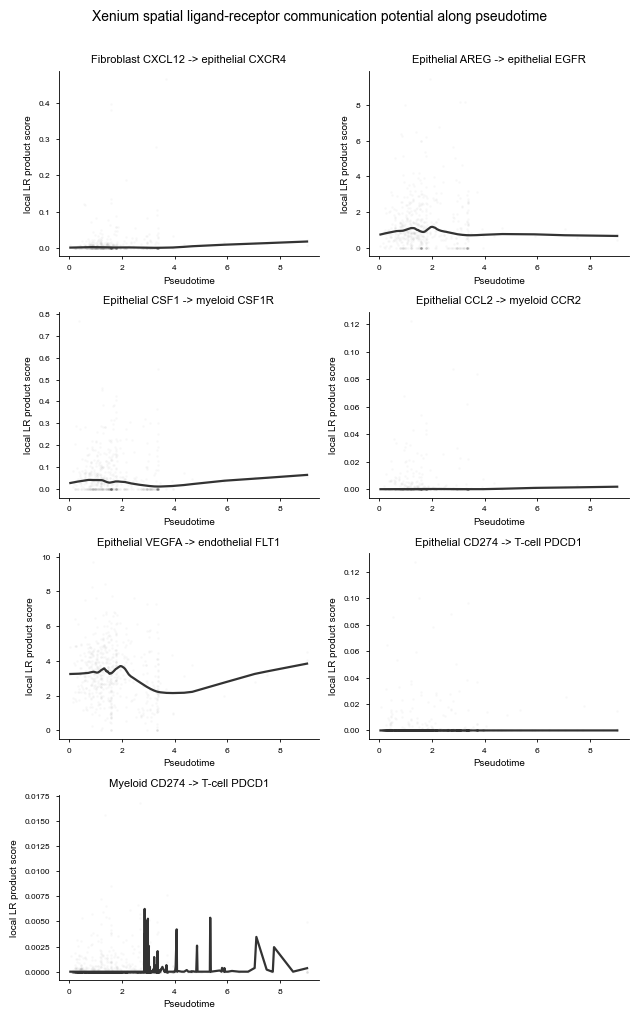

,group,category,feature,label,n,spearman_r,spearman_p,early_q10_median,late_q90_median,late_minus_early_median,mannwhitney_p_early_vs_late
5,Xenium spatial ligand-receptor communication p...,LR,lr__pancreatic_ductal_epithelium__to__T_cells_...,Epithelial CD274 -> T-cell PDCD1,4877,0.060894,0.000021,0.000000,0.000000,0.000000,0.001970
6,Xenium spatial ligand-receptor communication p...,LR,lr__Myeloid_cells__to__T_cells__CD274__PDCD1,Myeloid CD274 -> T-cell PDCD1,4877,0.048187,0.000762,0.000000,0.000000,0.000000,0.017335
0,Xenium spatial ligand-receptor communication p...,LR,lr__Fibroblasts__to__pancreatic_ductal_epithel...,Fibroblast CXCL12 -> epithelial CXCR4,585,-0.036602,0.376869,0.000000,0.000000,0.000000,0.952018
1,Xenium spatial ligand-receptor communication p...,LR,lr__pancreatic_ductal_epithelium__to__pancreat...,Epithelial AREG -> epithelial EGFR,587,-0.065262,0.114227,0.812999,0.671243,-0.141756,0.203500
3,Xenium spatial ligand-receptor communication p...,LR,lr__pancreatic_ductal_epithelium__to__Myeloid_...,Epithelial CCL2 -> myeloid CCR2,587,-0.074646,0.070731,0.000000,0.000000,0.000000,0.320095
2,Xenium spatial ligand-receptor communication p...,LR,lr__pancreatic_ductal_epithelium__to__Myeloid_...,Epithelial CSF1 -> myeloid CSF1R,587,-0.144161,0.000459,0.035904,0.000000,-0.035904,0.011455
4,Xenium spatial ligand-receptor communication p...,LR,lr__pancreatic_ductal_epithelium__to__Endothel...,Epithelial VEGFA -> endothelial FLT1,587,-0.147909,0.000324,3.132620,2.252102,-0.880518,0.002717


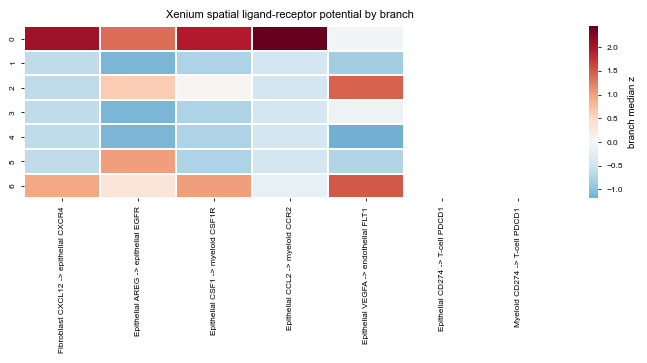

,lr__Fibroblasts__to__pancreatic_ductal_epithelium__CXCL12__CXCR4,lr__pancreatic_ductal_epithelium__to__pancreatic_ductal_epithelium__AREG__EGFR,lr__pancreatic_ductal_epithelium__to__Myeloid_cells__CSF1__CSF1R,lr__pancreatic_ductal_epithelium__to__Myeloid_cells__CCL2__CCR2,lr__pancreatic_ductal_epithelium__to__Endothelial_cells__VEGFA__FLT1,lr__pancreatic_ductal_epithelium__to__T_cells__CD274__PDCD1,lr__Myeloid_cells__to__T_cells__CD274__PDCD1
major_branch,,,,,,,
trunk,0.011681,1.391294,0.059342,0.010675,1.921691,0.0,0.0
other,0.000000,0.000000,0.000000,0.000000,1.148126,0.0,0.0
branch 3,0.000000,0.980752,0.017834,0.000000,3.373972,0.0,0.0
branch 2,0.000000,0.000000,0.000000,0.000000,1.868906,0.0,0.0
branch 4,0.000000,0.000000,0.000000,0.000000,0.827031,0.0,0.0
branch 5,0.000000,1.199303,0.000000,0.000000,1.267096,0.0,0.0
branch 1,0.006771,0.802271,0.039327,0.000937,3.463842,0.0,0.0


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/User

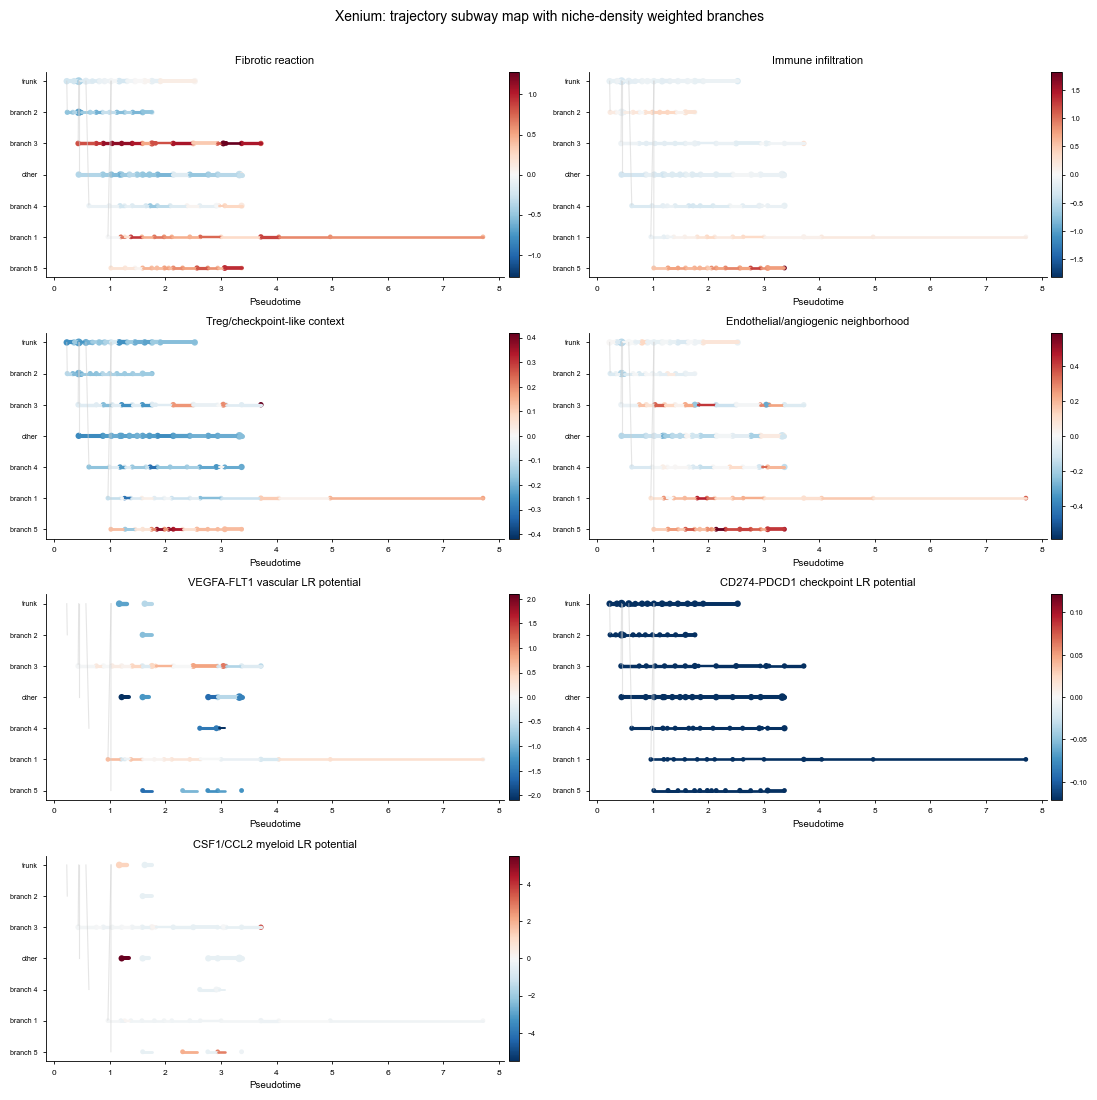

PosixPath('/Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/tables/xenium_trajectory_subway_map_key_programs.csv')

In [9]:
def expr_col(compartment, gene, source_or_target):
    gene_col = f"{gene}_lr_expr"
    if compartment == "pancreatic ductal epithelium":
        return f"source__pancreatic_ductal_epithelium__{gene_col}__mean"
    return f"surround__{safe_label(compartment)}__{gene_col}__mean"

def prop_col(compartment):
    if compartment == "pancreatic ductal epithelium":
        return None
    return f"surround_prop__{safe_label(compartment)}"

def add_lr_scores(lr_context_df, trajectory_df):
    merged = lr_context_df.merge(
        trajectory_df[
            [
                XENIUM_KEY, "sample_id", "display_name", "disease_group",
                "major_branch", "xenium_pseudotime_sample_centered",
                "xenium_pseudotime", "xenium_pseudotime_intrinsic_sample_centered",
            ]
            + [c for c in trajectory_df.columns if c.startswith("histology__")]
        ].drop_duplicates([XENIUM_KEY, "sample_id"]),
        on=[XENIUM_KEY, "sample_id"],
        how="left",
    )
    score_rows = []
    wide = merged[[XENIUM_KEY, "sample_id", "display_name", "disease_group", "major_branch", "xenium_pseudotime_sample_centered"]].copy()
    for pair in CANDIDATE_LR_PAIRS:
        ligand_col = expr_col(pair["source"], pair["ligand"], "source")
        receptor_col = expr_col(pair["target"], pair["receptor"], "target")
        required = [ligand_col, receptor_col]
        if not all(c in merged.columns for c in required):
            continue
        ligand = pd.to_numeric(merged[ligand_col], errors="coerce")
        receptor = pd.to_numeric(merged[receptor_col], errors="coerce")
        score = ligand * receptor
        for compartment in [pair["source"], pair["target"]]:
            pcol = prop_col(compartment)
            if pcol is not None and pcol in merged.columns:
                score = score * np.sqrt(pd.to_numeric(merged[pcol], errors="coerce").fillna(0).clip(lower=0))
        score_name = f"lr__{safe_label(pair['source'])}__to__{safe_label(pair['target'])}__{pair['ligand']}__{pair['receptor']}"
        wide[score_name] = score
        score_rows.append({**pair, "score": score_name, "ligand_col": ligand_col, "receptor_col": receptor_col, "n_nonnull": int(score.notna().sum())})
    score_meta_df = pd.DataFrame(score_rows)
    return wide, score_meta_df

xenium_lr_score_df, xenium_lr_score_meta_df = add_lr_scores(xenium_lr_context_df, xenium_result_df)
display(xenium_lr_score_meta_df)
save_df(xenium_lr_score_meta_df, TABLE_DIR / "xenium_lr_score_metadata.csv")
save_df(xenium_lr_score_df, TABLE_DIR / "xenium_lr_scores_by_niche.pkl")

LR_FEATURE_SPECS = [
    {"feature": row["score"], "label": row["label"], "category": "LR", "color": "#333333"}
    for _, row in xenium_lr_score_meta_df.iterrows()
    if row["n_nonnull"] >= 30
]
lr_score_cols = [spec["feature"] for spec in LR_FEATURE_SPECS if spec["feature"] in xenium_lr_score_df.columns]

xenium_lr_trend_df = plot_lowess_feature_panel(
    xenium_lr_score_df,
    LR_FEATURE_SPECS,
    pseudotime_col="xenium_pseudotime_sample_centered",
    title="Xenium spatial ligand-receptor communication potential along pseudotime",
    ylabel="local LR product score",
    n_cols=2,
    figsize_scale=2.5,
    lowess_frac=0.35,
    min_n=30,
    save_name="xenium_lr_potential_trends.png",
)
display(xenium_lr_trend_df)
save_df(xenium_lr_trend_df, TABLE_DIR / "xenium_lr_potential_trends.csv")

xenium_lr_branch_df = plot_branch_heatmap(
    xenium_lr_score_df,
    LR_FEATURE_SPECS,
    branch_col="major_branch",
    title="Xenium spatial ligand-receptor potential by branch",
    save_name="xenium_lr_branch_heatmap.png",
)
display(xenium_lr_branch_df)
save_df(xenium_lr_branch_df.reset_index(), TABLE_DIR / "xenium_lr_branch_medians.csv")

lr_label_to_score = dict(zip(xenium_lr_score_meta_df["label"], xenium_lr_score_meta_df["score"])) if not xenium_lr_score_meta_df.empty else {}
lr_tree_df = xenium_lr_score_df[[XENIUM_KEY, "sample_id"] + lr_score_cols].copy()
xenium_context_df = xenium_context_df.merge(lr_tree_df, on=[XENIUM_KEY, "sample_id"], how="left")
xenium_context_df["atlas__vascular_lr_potential"] = zmean(
    xenium_context_df,
    [lr_label_to_score.get("Epithelial VEGFA -> endothelial FLT1", "__missing__")],
)
xenium_context_df["atlas__checkpoint_lr_potential"] = zmean(
    xenium_context_df,
    [
        lr_label_to_score.get("Epithelial CD274 -> T-cell PDCD1", "__missing__"),
        lr_label_to_score.get("Myeloid CD274 -> T-cell PDCD1", "__missing__"),
    ],
)
xenium_context_df["atlas__myeloid_recruitment_lr_potential"] = zmean(
    xenium_context_df,
    [
        lr_label_to_score.get("Epithelial CSF1 -> myeloid CSF1R", "__missing__"),
        lr_label_to_score.get("Epithelial CCL2 -> myeloid CCR2", "__missing__"),
    ],
)
XENIUM_TREE_FEATURES_WITH_LR = XENIUM_TREE_FEATURES + [
    {"feature": "atlas__vascular_lr_potential", "label": "VEGFA-FLT1 vascular LR potential", "category": "LR atlas"},
    {"feature": "atlas__checkpoint_lr_potential", "label": "CD274-PDCD1 checkpoint LR potential", "category": "LR atlas"},
    {"feature": "atlas__myeloid_recruitment_lr_potential", "label": "CSF1/CCL2 myeloid LR potential", "category": "LR atlas"},
]

xenium_tree_curve_df = plot_trajectory_subway_map_grid(
    xenium_context_df,
    branch_col="major_branch",
    pseudotime_col="xenium_pseudotime_sample_centered",
    feature_specs=XENIUM_TREE_FEATURES_WITH_LR,
    title_prefix="Xenium: trajectory subway map with niche-density weighted branches",
    n_cols=2,
    n_bins=16,
    min_bin_n=10,
    save_name="xenium_trajectory_subway_map_key_programs.png",
)
save_df(xenium_tree_curve_df, TABLE_DIR / "xenium_trajectory_subway_map_key_programs.csv")


## Stage 7. Xenium: branch-time niche evolution and communication atlas

Same branch-time atlas approach applied to Xenium, now incorporating microenvironment
composition, cell-type status genes, AND ligand-receptor product scores in each branch's
early/mid/late state cards.


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/User

,dataset,branch,time_bin,branch_time_state,n_niches,pseudotime_median,branch_interpretation,top_enriched_features,top_depleted_features
0,xenium,branch 1,early,branch 1 | early,124,1.272581,glandular architecture / differentiated tumor,"Epithelial VEGFA -> endothelial FLT1 (LR, z=+1...","Myeloid CD163 (myeloid status, z=-1.34); Myelo..."
1,xenium,branch 1,mid,branch 1 | mid,126,2.264237,glandular architecture / differentiated tumor,"Epithelial VEGFA -> endothelial FLT1 (LR, z=+1...","Myeloid CD163 (myeloid status, z=-1.08); Myelo..."
2,xenium,branch 1,late,branch 1 | late,121,3.987924,glandular architecture / differentiated tumor,"Treg/checkpoint-like context (atlas, z=+1.50);...","Neighborhood mixing (neighborhood program, z=-..."
3,xenium,branch 2,early,branch 2 | early,198,0.437366,ADM / PanIN-like remodeling + normal / residua...,"Plasma MZB1 (B-lineage status, z=+0.92); Neigh...","Fibroblast ACTA2 (fibroblast status, z=-2.28);..."
4,xenium,branch 2,mid,branch 2 | mid,197,0.811768,ADM / PanIN-like remodeling + normal / residua...,"T-cell prop. (composition, z=+1.30); Neighborh...","Fibroblast ACTA2 (fibroblast status, z=-1.30);..."
5,xenium,branch 2,late,branch 2 | late,198,1.559190,ADM / PanIN-like remodeling + normal / residua...,"Neighborhood mixing (neighborhood program, z=+...","Fibroblast THY1 (fibroblast status, z=-1.25); ..."
6,xenium,branch 3,early,branch 3 | early,232,0.898734,interface-disrupted budding / stromal-contact ...,"Fibroblast THY1 (fibroblast status, z=+2.43); ...","T CD3D (T-cell status, z=-3.18); B CD79A (B-li..."
7,xenium,branch 3,mid,branch 3 | mid,232,1.757987,interface-disrupted budding / stromal-contact ...,"Fibroblast PDPN (fibroblast status, z=+2.36); ...","B CD79A (B-lineage status, z=-2.94); Plasma MZ..."
8,xenium,branch 3,late,branch 3 | late,232,3.043151,interface-disrupted budding / stromal-contact ...,"Myeloid CD68 (myeloid status, z=+2.76); Fibrob...",Neighborhood cytotoxic T (neighborhood program...
9,xenium,branch 4,early,branch 4 | early,188,1.182784,immune-excluded gland-poor / undifferentiated-...,"T CD3D (T-cell status, z=+1.15); Myeloid CD163...","Endothelial prop. (composition, z=-1.09); Neig..."


,dataset,branch,transition,max_abs_delta,max_abs_delta_z,top_changes,top_categories
0,xenium,branch 5,branch 5: mid -> late,3.931285,4.533478,"B MS4A1 increase (raw +0.58, z +4.5); Epitheli...","LR, B-lineage status, fibroblast status"
1,xenium,other,other: early -> mid,5.984178,4.215466,Epithelial CCL2 -> myeloid CCR2 decrease (raw ...,"LR, LR atlas, myeloid status"
2,xenium,branch 5,branch 5: early -> mid,3.378601,3.930206,Epithelial CSF1 -> myeloid CSF1R increase (raw...,"LR, fibroblast status, neighborhood program"
3,xenium,trunk,trunk: mid -> late,2.158161,3.347723,"Myeloid S100A9 decrease (raw -1.6, z -3.3); Fi...","fibroblast status, LR, myeloid status"
4,xenium,branch 3,branch 3: mid -> late,3.924382,2.971644,"B CD79A increase (raw +3.9, z +3); Plasma MZB1...","B-lineage status, T-cell status, myeloid status"
5,xenium,branch 4,branch 4: mid -> late,1.461194,2.537914,"Myeloid CD163 increase (raw +1.5, z +2.5); Mye...","myeloid status, fibroblast status"
6,xenium,other,other: mid -> late,1.268836,2.266674,"Myeloid C1QB increase (raw +0.31, z +2.3); Mye...","myeloid status, B-lineage status, fibroblast s..."
7,xenium,branch 3,branch 3: early -> mid,0.893929,2.154220,"Fibroblast PDPN increase (raw +0.22, z +2.2); ...","fibroblast status, T-cell status, composition"
8,xenium,branch 4,branch 4: early -> mid,1.087958,1.889650,"Myeloid CD163 decrease (raw -1.1, z -1.9); Nei...","myeloid status, neighborhood program, T-cell s..."
9,xenium,branch 1,branch 1: mid -> late,0.739956,1.758829,"Myeloid CD68 increase (raw +0.11, z +1.8); Nei...","myeloid status, neighborhood program, atlas"


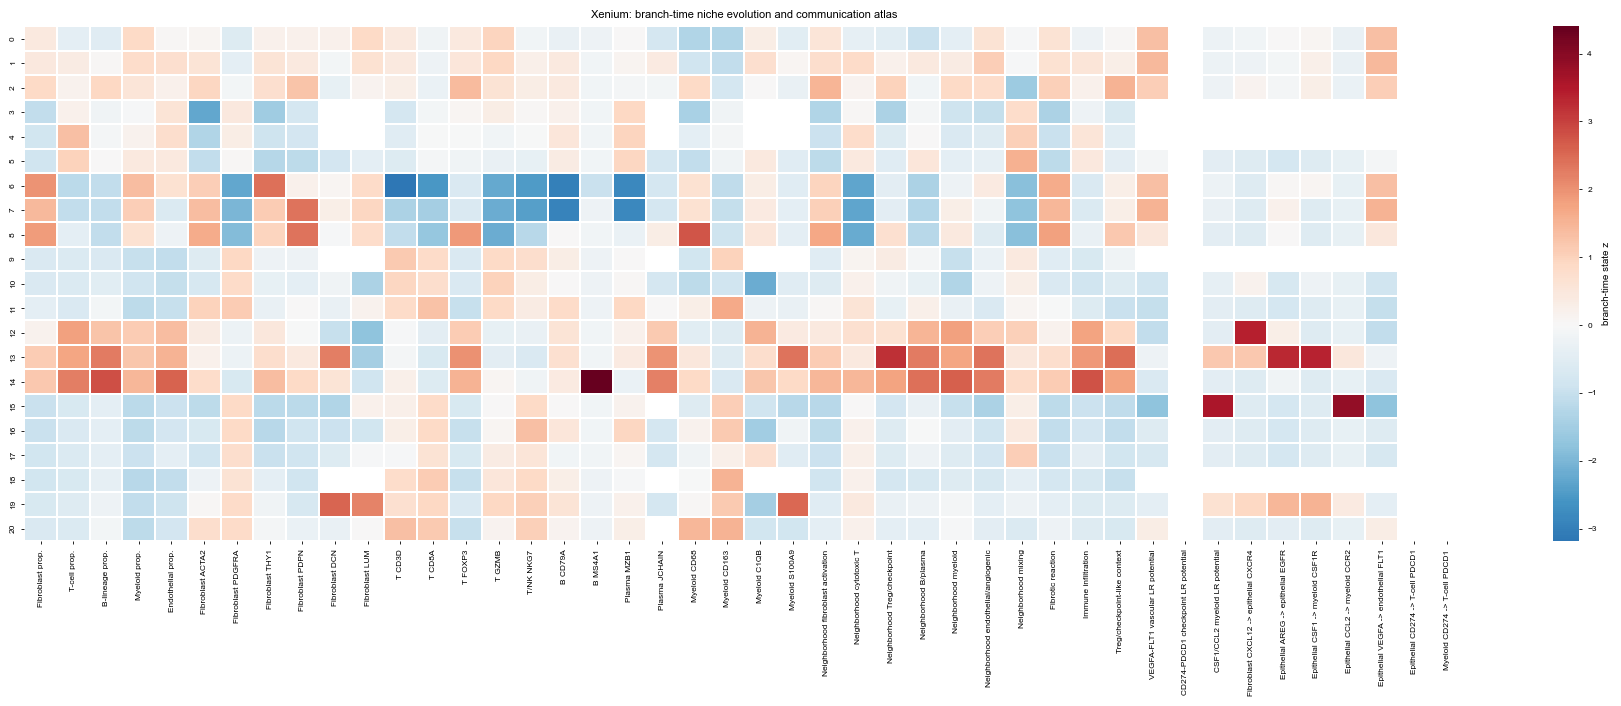

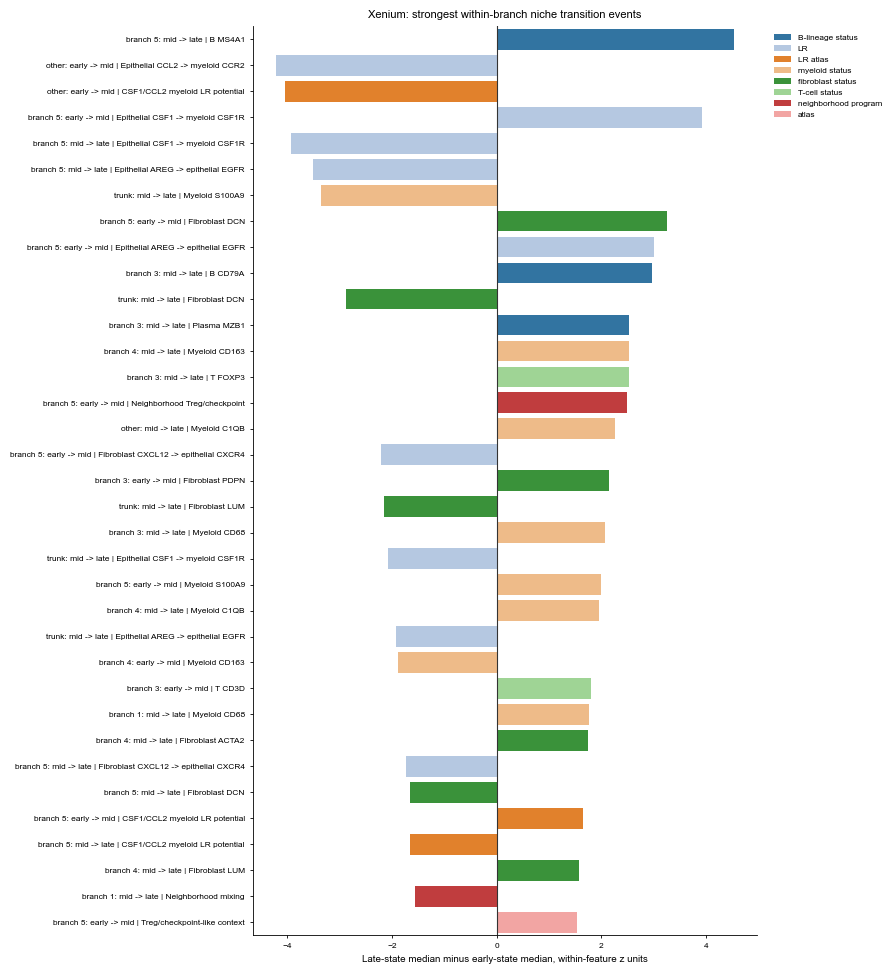

PosixPath('/Users/shihongwu/SpatioEv/notebooks/results/trajectory_microenvironment_interactions/tables/xenium_branch_time_transition_events.csv')

In [10]:
# ── Xenium branch-time atlas (composition + status + LR) ───────────────────────
# [reason] Combining microenvironment features with LR scores per branch-time
# state reveals which immune and stromal communication events emerge or resolve
# within each branch — a manuscript-ready transition summary.
xenium_branch_biology_map = {}
if {"branch", "suggested_biology"}.issubset(xenium_branch_summary_df.columns):
    xenium_branch_biology_map = dict(
        zip(xenium_branch_summary_df["branch"].astype(str), xenium_branch_summary_df["suggested_biology"].astype(str))
    )

lr_score_cols = [
    row["score"]
    for _, row in xenium_lr_score_meta_df.iterrows()
    if row["score"] in xenium_lr_score_df.columns and row["n_nonnull"] >= 30
]
missing_lr_cols = [c for c in lr_score_cols if c not in xenium_context_df.columns]
if missing_lr_cols:
    xenium_atlas_df = xenium_context_df.merge(
        xenium_lr_score_df[[XENIUM_KEY, "sample_id"] + missing_lr_cols],
        on=[XENIUM_KEY, "sample_id"],
        how="left",
    )
else:
    xenium_atlas_df = xenium_context_df.copy()
xenium_atlas_specs = (
    XENIUM_MICROENV_FEATURES
    + XENIUM_NEIGHBORHOOD_PROGRAM_FEATURES
    + XENIUM_TREE_FEATURES_WITH_LR
    + LR_FEATURE_SPECS
)

xenium_branch_time_df = add_branch_time_bins(
    xenium_atlas_df,
    branch_col="major_branch",
    pseudotime_col="xenium_pseudotime_sample_centered",
    min_branch_n=30,
)
xenium_state_summary_df, xenium_state_feature_df = state_feature_matrix(
    xenium_branch_time_df,
    xenium_atlas_specs,
    branch_col="major_branch",
    pseudotime_col="xenium_pseudotime_sample_centered",
    dataset_label="xenium",
)
xenium_state_card_df = build_state_cards(
    xenium_state_feature_df,
    xenium_atlas_specs,
    branch_biology_map=xenium_branch_biology_map,
    top_n=5,
)
xenium_transition_df = compute_branch_time_transitions(
    xenium_state_feature_df,
    xenium_atlas_specs,
    dataset_label="xenium",
)
xenium_transition_event_df = summarize_transition_events(xenium_transition_df, top_n_per_transition=5)

display(xenium_state_card_df.head(25))
display(xenium_transition_event_df.head(25))

plot_branch_time_state_heatmap(
    xenium_state_feature_df,
    xenium_atlas_specs,
    title="Xenium: branch-time niche evolution and communication atlas",
    save_name="xenium_branch_time_state_heatmap.png",
)
plot_transition_event_bars(
    xenium_transition_df,
    title="Xenium: strongest within-branch niche transition events",
    save_name="xenium_branch_time_transition_events.png",
    top_n=35,
)

save_df(xenium_state_summary_df, TABLE_DIR / "xenium_branch_time_state_summary.csv")
save_df(xenium_state_card_df, TABLE_DIR / "xenium_branch_time_state_cards.csv")
save_df(xenium_transition_df, TABLE_DIR / "xenium_branch_time_transition_feature_deltas.csv")
save_df(xenium_transition_event_df, TABLE_DIR / "xenium_branch_time_transition_events.csv")


## Stage 8. Integrated interpretation — cross-modality top changes

Pool the Spearman-ranked trends and branch-time transition events from both modalities
into a single summary. Features and LR pairs that rank highly in both IMC and Xenium
represent the most robust findings for the manuscript.


In [11]:
# ── Cross-modality integrated summary ───────────────────────────────────────────
# [reason] Top Spearman-ranked features from each analysis stream are pooled.
# Features appearing in both IMC and Xenium (e.g. fibroblast FAP/ACTA2 increasing)
# are the most manuscript-robust findings.
def summarize_top_changes(trend_df, label, top_n=8):
    if trend_df is None or trend_df.empty:
        return pd.DataFrame()
    out = trend_df.copy()
    out["analysis"] = label
    out["abs_spearman_r"] = out["spearman_r"].abs()
    return out.sort_values("abs_spearman_r", ascending=False).head(top_n)

top_change_df = pd.concat(
    [
        summarize_top_changes(mi_microenv_trend_df, "multiplexed microenvironment"),
        summarize_top_changes(mi_colocalization_trend_df, "multiplexed spatial co-localization"),
        summarize_top_changes(xenium_microenv_trend_df, "xenium microenvironment"),
        summarize_top_changes(xenium_neighborhood_program_trend_df, "xenium neighborhood programs"),
        summarize_top_changes(xenium_lr_trend_df, "xenium ligand-receptor"),
    ],
    ignore_index=True,
)
display(top_change_df[["analysis", "label", "category", "spearman_r", "late_minus_early_median", "n"]])
save_df(top_change_df, TABLE_DIR / "top_trajectory_microenvironment_changes.csv")

all_transition_df = pd.concat(
    [
        mi_transition_df,
        xenium_transition_df,
    ],
    ignore_index=True,
)
all_transition_event_df = pd.concat(
    [
        mi_transition_event_df,
        xenium_transition_event_df,
    ],
    ignore_index=True,
)
transition_category_summary_df = (
    all_transition_df
    .assign(abs_delta_z=lambda d: d["delta_z"].abs())
    .groupby(["dataset", "category"], observed=True)
    .agg(
        n_events=("delta", "size"),
        median_abs_delta_z=("abs_delta_z", "median"),
        max_abs_delta_z=("abs_delta_z", "max"),
        n_increases=("direction", lambda s: int((s == "increase").sum())),
        n_decreases=("direction", lambda s: int((s == "decrease").sum())),
    )
    .reset_index()
    .sort_values(["dataset", "max_abs_delta_z"], ascending=[True, False])
)

all_transition_event_df = all_transition_event_df.sort_values("max_abs_delta_z", ascending=False).reset_index(drop=True)

display(all_transition_event_df.head(30))
display(transition_category_summary_df)
save_df(all_transition_df, TABLE_DIR / "all_branch_time_transition_feature_deltas.csv")
save_df(all_transition_event_df, TABLE_DIR / "all_branch_time_transition_events.csv")
save_df(transition_category_summary_df, TABLE_DIR / "transition_category_summary.csv")

summary_lines = []
for analysis, sub in top_change_df.groupby("analysis", observed=True):
    summary_lines.append(f"## {analysis}")
    for _, row in sub.iterrows():
        direction = "increases" if row["spearman_r"] > 0 else "decreases"
        summary_lines.append(
            f"- {row['label']} {direction} along pseudotime "
            f"(Spearman r={row['spearman_r']:.2f}, late-early median={row['late_minus_early_median']:.3g})."
        )
summary_lines.append("## branch-time niche evolution events")
for _, row in all_transition_event_df.head(20).iterrows():
    summary_lines.append(
        f"- {row['dataset']} {row['transition']}: {row['top_changes']} "
        f"(strongest standardized |delta|={row['max_abs_delta_z']:.2g})."
    )
summary_text = "\n".join(summary_lines)
(OUTPUT_DIR / "trajectory_microenvironment_interpretation_summary.md").write_text(summary_text)
print(summary_text)


,analysis,label,category,spearman_r,late_minus_early_median,n
0,multiplexed microenvironment,Fibroblast proportion,composition,0.244996,2.932762e-01,46574
1,multiplexed microenvironment,Fibroblast FAP,fibroblast status,0.238489,1.835820e-01,46160
2,multiplexed microenvironment,Fibroblast PDPN,fibroblast status,0.141232,4.601252e-01,46160
3,multiplexed microenvironment,Endothelial proportion,composition,-0.106317,-1.858108e-02,46574
4,multiplexed microenvironment,B-lineage proportion,composition,0.082061,4.294019e-03,46574
5,multiplexed microenvironment,Vimentin-only mesenchyme prop.,composition,-0.075663,-8.815306e-02,46574
6,multiplexed microenvironment,Fibroblast Thy1,fibroblast status,-0.061240,-1.726966e-01,24871
7,multiplexed microenvironment,T-cell proportion,composition,0.054787,2.060973e-02,46574
8,multiplexed spatial co-localization,Ductal cells near Vimentin only mesenchyme,spatial co-localization,-0.206474,-1.084019e-01,46574
9,multiplexed spatial co-localization,Ductal cells near Endothelial cells,spatial co-localization,-0.172093,-3.921569e-02,46574


,dataset,branch,transition,max_abs_delta,max_abs_delta_z,top_changes,top_categories
0,xenium,branch 5,branch 5: mid -> late,3.931285,4.533478,"B MS4A1 increase (raw +0.58, z +4.5); Epitheli...","LR, B-lineage status, fibroblast status"
1,xenium,other,other: early -> mid,5.984178,4.215466,Epithelial CCL2 -> myeloid CCR2 decrease (raw ...,"LR, LR atlas, myeloid status"
2,xenium,branch 5,branch 5: early -> mid,3.378601,3.930206,Epithelial CSF1 -> myeloid CSF1R increase (raw...,"LR, fibroblast status, neighborhood program"
3,xenium,trunk,trunk: mid -> late,2.158161,3.347723,"Myeloid S100A9 decrease (raw -1.6, z -3.3); Fi...","fibroblast status, LR, myeloid status"
4,multiplexed imaging,branch 23,branch 23: mid -> late,0.234842,3.225367,Ductal-Vimentin only mesenchyme excess decreas...,"spatial co-localization, fibroblast status, co..."
5,multiplexed imaging,branch 23.a,branch 23.a: mid -> late,0.229465,3.151527,Ductal-Vimentin only mesenchyme excess increas...,"spatial co-localization, composition"
6,multiplexed imaging,branch 23.a,branch 23.a: early -> mid,0.229465,3.151527,Ductal-Vimentin only mesenchyme excess decreas...,"spatial co-localization, fibroblast status, co..."
7,multiplexed imaging,branch 23.b,branch 23.b: mid -> late,0.291668,3.020379,Ductal-Vimentin only mesenchyme excess increas...,"spatial co-localization, fibroblast status, co..."
8,xenium,branch 3,branch 3: mid -> late,3.924382,2.971644,"B CD79A increase (raw +3.9, z +3); Plasma MZB1...","B-lineage status, T-cell status, myeloid status"
9,xenium,branch 4,branch 4: mid -> late,1.461194,2.537914,"Myeloid CD163 increase (raw +1.5, z +2.5); Mye...","myeloid status, fibroblast status"


,dataset,category,n_events,median_abs_delta_z,max_abs_delta_z,n_increases,n_decreases
3,multiplexed imaging,spatial co-localization,240,0.000000,3.225367,50,190
2,multiplexed imaging,fibroblast status,96,0.430224,2.580573,58,38
1,multiplexed imaging,composition,120,0.432625,2.381988,69,51
0,multiplexed imaging,atlas,72,0.320369,1.156209,42,30
4,xenium,B-lineage status,50,0.181767,4.533478,28,22
5,xenium,LR,78,0.193672,4.215466,14,64
6,xenium,LR atlas,34,0.298542,4.050285,7,27
11,xenium,myeloid status,48,0.416675,3.347723,32,16
10,xenium,fibroblast status,76,0.287590,3.259466,46,30
7,xenium,T-cell status,70,0.210995,2.531296,33,37


## multiplexed microenvironment
- Fibroblast proportion increases along pseudotime (Spearman r=0.24, late-early median=0.293).
- Fibroblast FAP increases along pseudotime (Spearman r=0.24, late-early median=0.184).
- Fibroblast PDPN increases along pseudotime (Spearman r=0.14, late-early median=0.46).
- Endothelial proportion decreases along pseudotime (Spearman r=-0.11, late-early median=-0.0186).
- B-lineage proportion increases along pseudotime (Spearman r=0.08, late-early median=0.00429).
- Vimentin-only mesenchyme prop. decreases along pseudotime (Spearman r=-0.08, late-early median=-0.0882).
- Fibroblast Thy1 decreases along pseudotime (Spearman r=-0.06, late-early median=-0.173).
- T-cell proportion increases along pseudotime (Spearman r=0.05, late-early median=0.0206).
## multiplexed spatial co-localization
- Ductal cells near Vimentin only mesenchyme decreases along pseudotime (Spearman r=-0.21, late-early median=-0.108).
- Ductal cells near Endothelial cells decreases along p

## Notes

**Interpretation guardrails:**

- IMC has stronger protein/pixel-level fibroblast status readouts but limited immune subtype resolution.
- Xenium has richer immune/fibroblast/myeloid status genes but the LR scores are transcript-level proxies — confirm with CellChat/SpatialCellChat (see `07_xenium_05_spatialcellchat.R`).
- The branch-time transition atlas highlights *within-branch* dynamics that global LOWESS trends obscure. Transitions with large `delta_z` values and consistent direction across images are the most reliable manuscript claims.
- Feature selection bias: only features present in both early and late state cells contribute to each transition. Low-count branches may lack statistical power.

**Future sv.tl integration:**  
The branch-time atlas helpers (`state_feature_matrix`, `build_state_cards`,
`compute_branch_time_transitions`, `summarize_transition_events`,
`plot_branch_time_state_heatmap`, `plot_transition_event_bars`) are candidates for
inclusion in a future `sv.tl.pseudotime` release.
